# mCREAM Ensemble Analysis

Analysis notebook for the ensemble experiments (`mcream_ensemble_main.py`).

**Experiment matrix:**
- `average`  hard expert + simple average 
- `weighted`  hard expert + learnable π 
<!-- - `soft_average` — soft-edge α + simple average (edge-level learning)
- `soft_weighted` — soft-edge α + learnable π (full proposed method) -->

**Noise families:** deletion / addition / reversal × low / medium / high

**Datasets:** Complete_Concept_FMNIST, CelebA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import torch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── CONFIGURE ────────────────────────────────────────────────────────────────
EXPERIMENTS_ROOT  = Path("/home/dani00003/mCREAM/experiments")
GRAPHS_ROOT       = Path("/home/dani00003/mCREAM/data")
DAG_CFMNIST       = Path("/home/dani00003/mCREAM/data/FashionMNIST/Complete_Concept_FMNIST_DAG.csv")
DAG_CELEBA        = Path("/home/dani00003/mCREAM/data/CelebA/final_DAG_unfair.csv")

DATASETS    = ["Complete_Concept_FMNIST", "CelebA"]
ACTIONS     = ["deletion", "addition", "reversal"]
LEVELS      = ["low", "medium", "high"]
ETYPES      = ["average", "weighted", "soft_average", "soft_weighted"]
ETYPE_LABEL = {
    "average":      "Avg (hard)",
    "weighted":     "Weighted π (hard)",
    "soft_average": "Avg (soft α)",
    "soft_weighted":"Weighted α+π (full)",
}
ACTION_COLOR = {"deletion": "#e74c3c", "addition": "#2ecc71", "reversal": "#3498db"}
ETYPE_MARKER = {"average": "o", "weighted": "s", "soft_average": "^", "soft_weighted": "D"}

print(f"Experiments root exists: {EXPERIMENTS_ROOT.exists()}")

Experiments root exists: True


## 1. Ground Truth DAGs

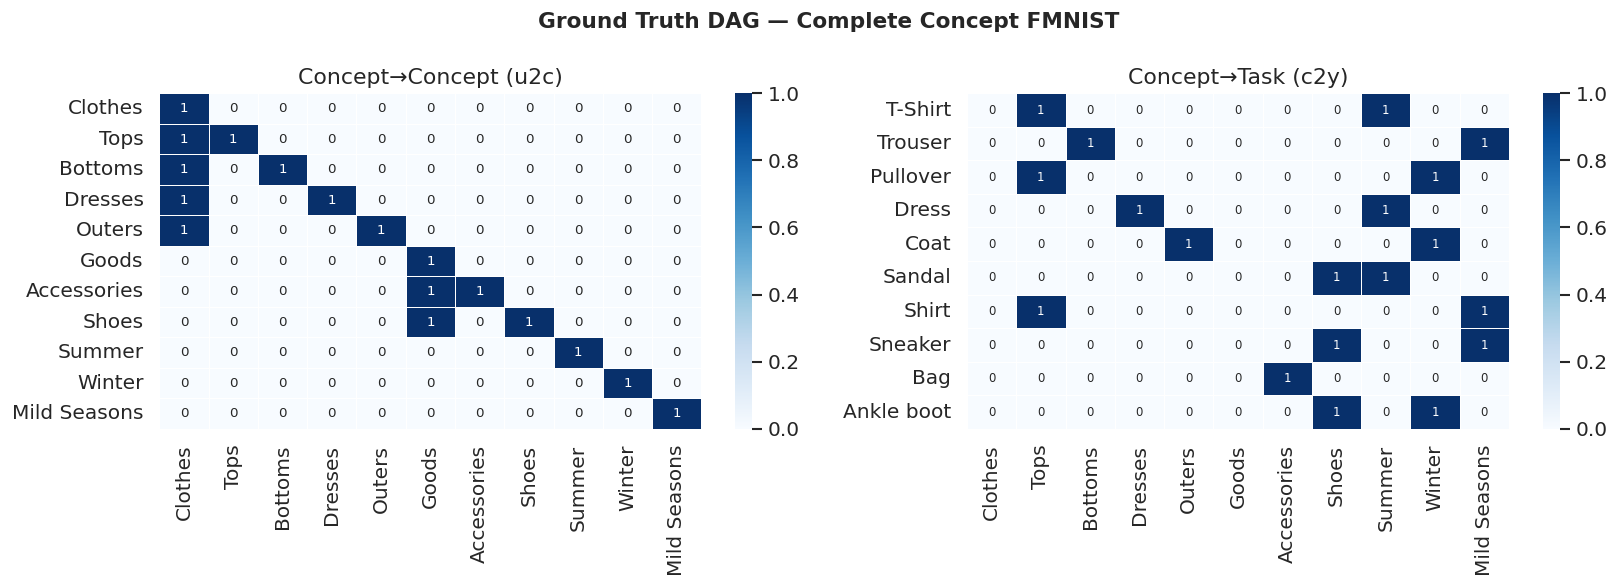

  u2c edges: 17  |  c2y edges: 19


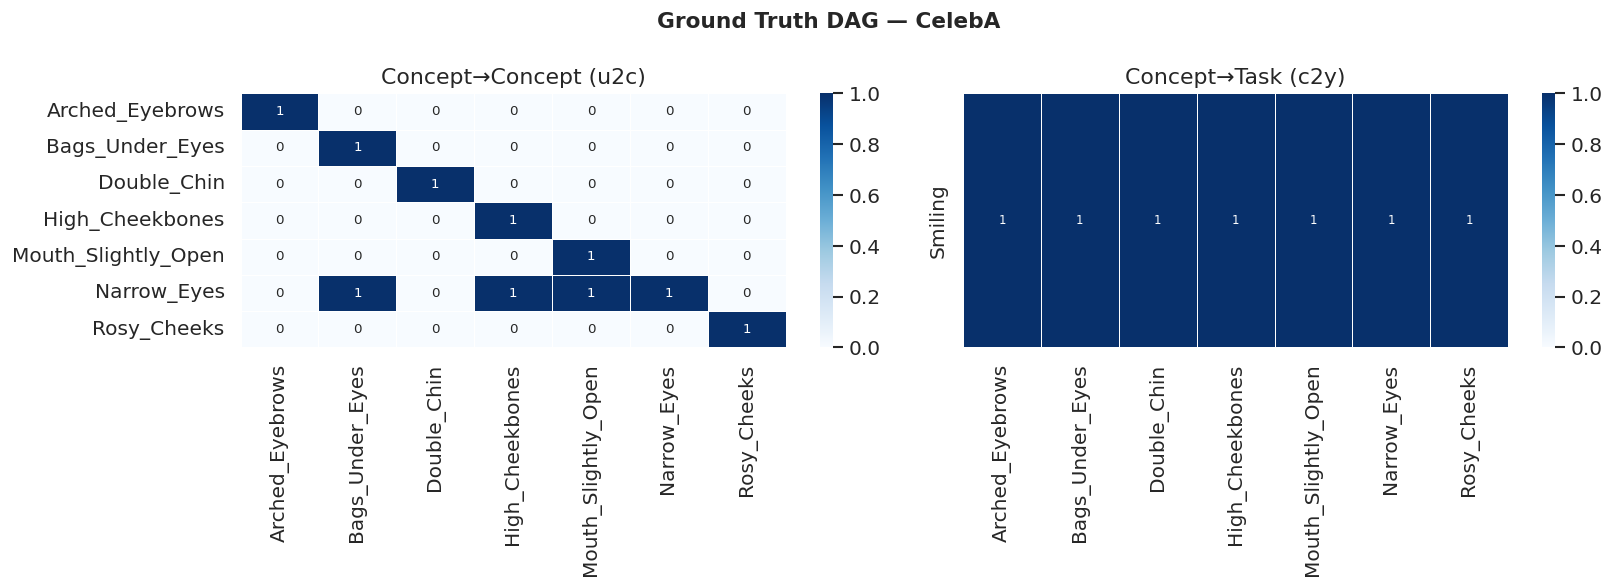

  u2c edges: 10  |  c2y edges: 7


In [2]:
def plot_dag(dag_path: Path, title: str, num_concepts: int):
    if not dag_path.exists():
        print(f"DAG not found: {dag_path}"); return
    df = pd.read_csv(dag_path, index_col=0)
    vals = (df.values != 0).astype(float)
    # Show only concept rows/cols for clarity
    u2c = vals[:num_concepts, :num_concepts]
    c2y = vals[num_concepts:, :num_concepts]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    concepts = df.columns[:num_concepts].tolist()
    tasks    = df.columns[num_concepts:].tolist()

    sns.heatmap(u2c, ax=axes[0], cmap="Blues", vmin=0, vmax=1,
                xticklabels=concepts, yticklabels=concepts,
                annot=True, fmt=".0f", linewidths=0.5, annot_kws={"size": 8})
    axes[0].set_title("Concept→Concept (u2c)")

    sns.heatmap(c2y, ax=axes[1], cmap="Blues", vmin=0, vmax=1,
                xticklabels=concepts, yticklabels=tasks,
                annot=True, fmt=".0f", linewidths=0.5, annot_kws={"size": 7})
    axes[1].set_title("Concept→Task (c2y)")

    fig.suptitle(f"Ground Truth DAG — {title}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"  u2c edges: {int(u2c.sum())}  |  c2y edges: {int(c2y.sum())}")

plot_dag(DAG_CFMNIST, "Complete Concept FMNIST", num_concepts=11)
plot_dag(DAG_CELEBA,  "CelebA", num_concepts=7)

## 2. Expert Graph Examples (one per action × noise level)

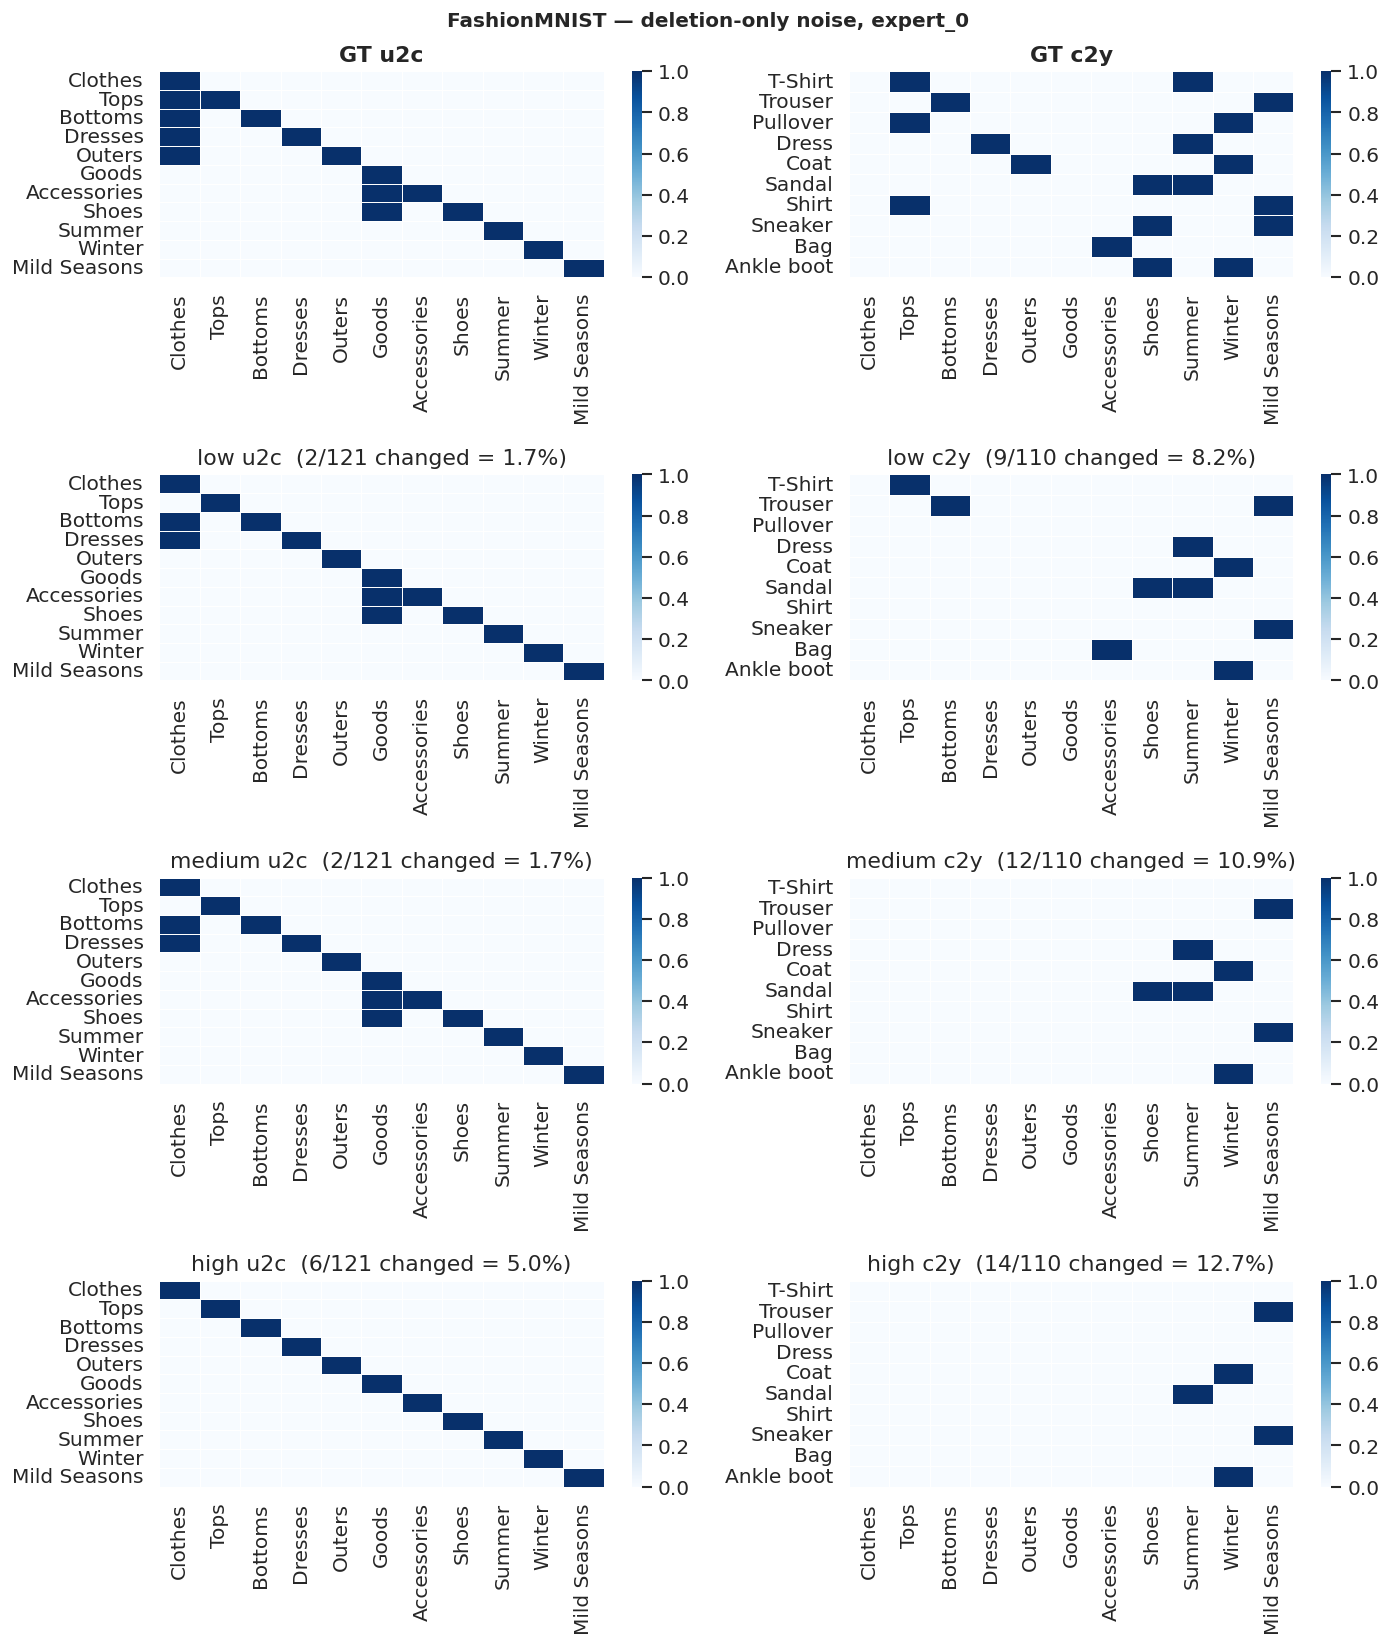

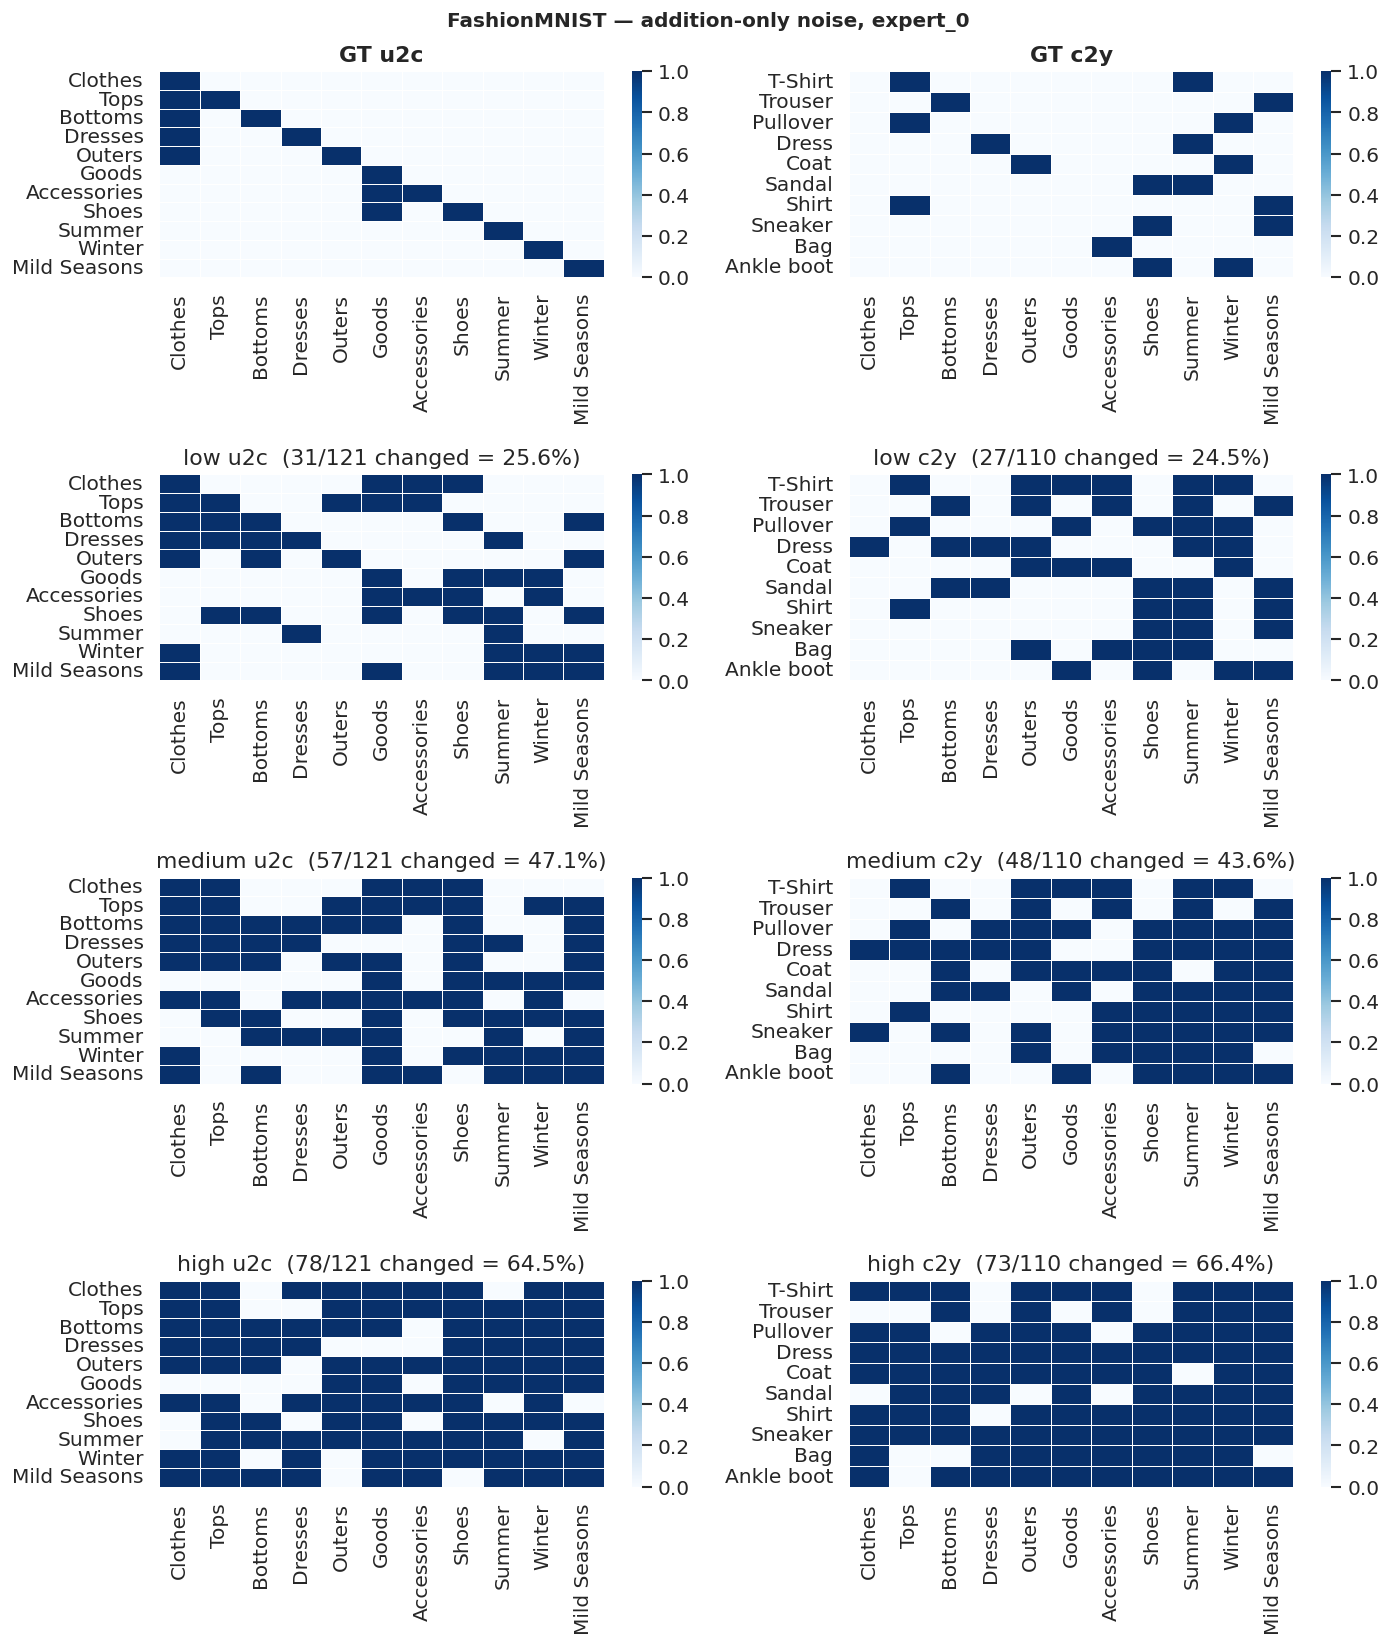

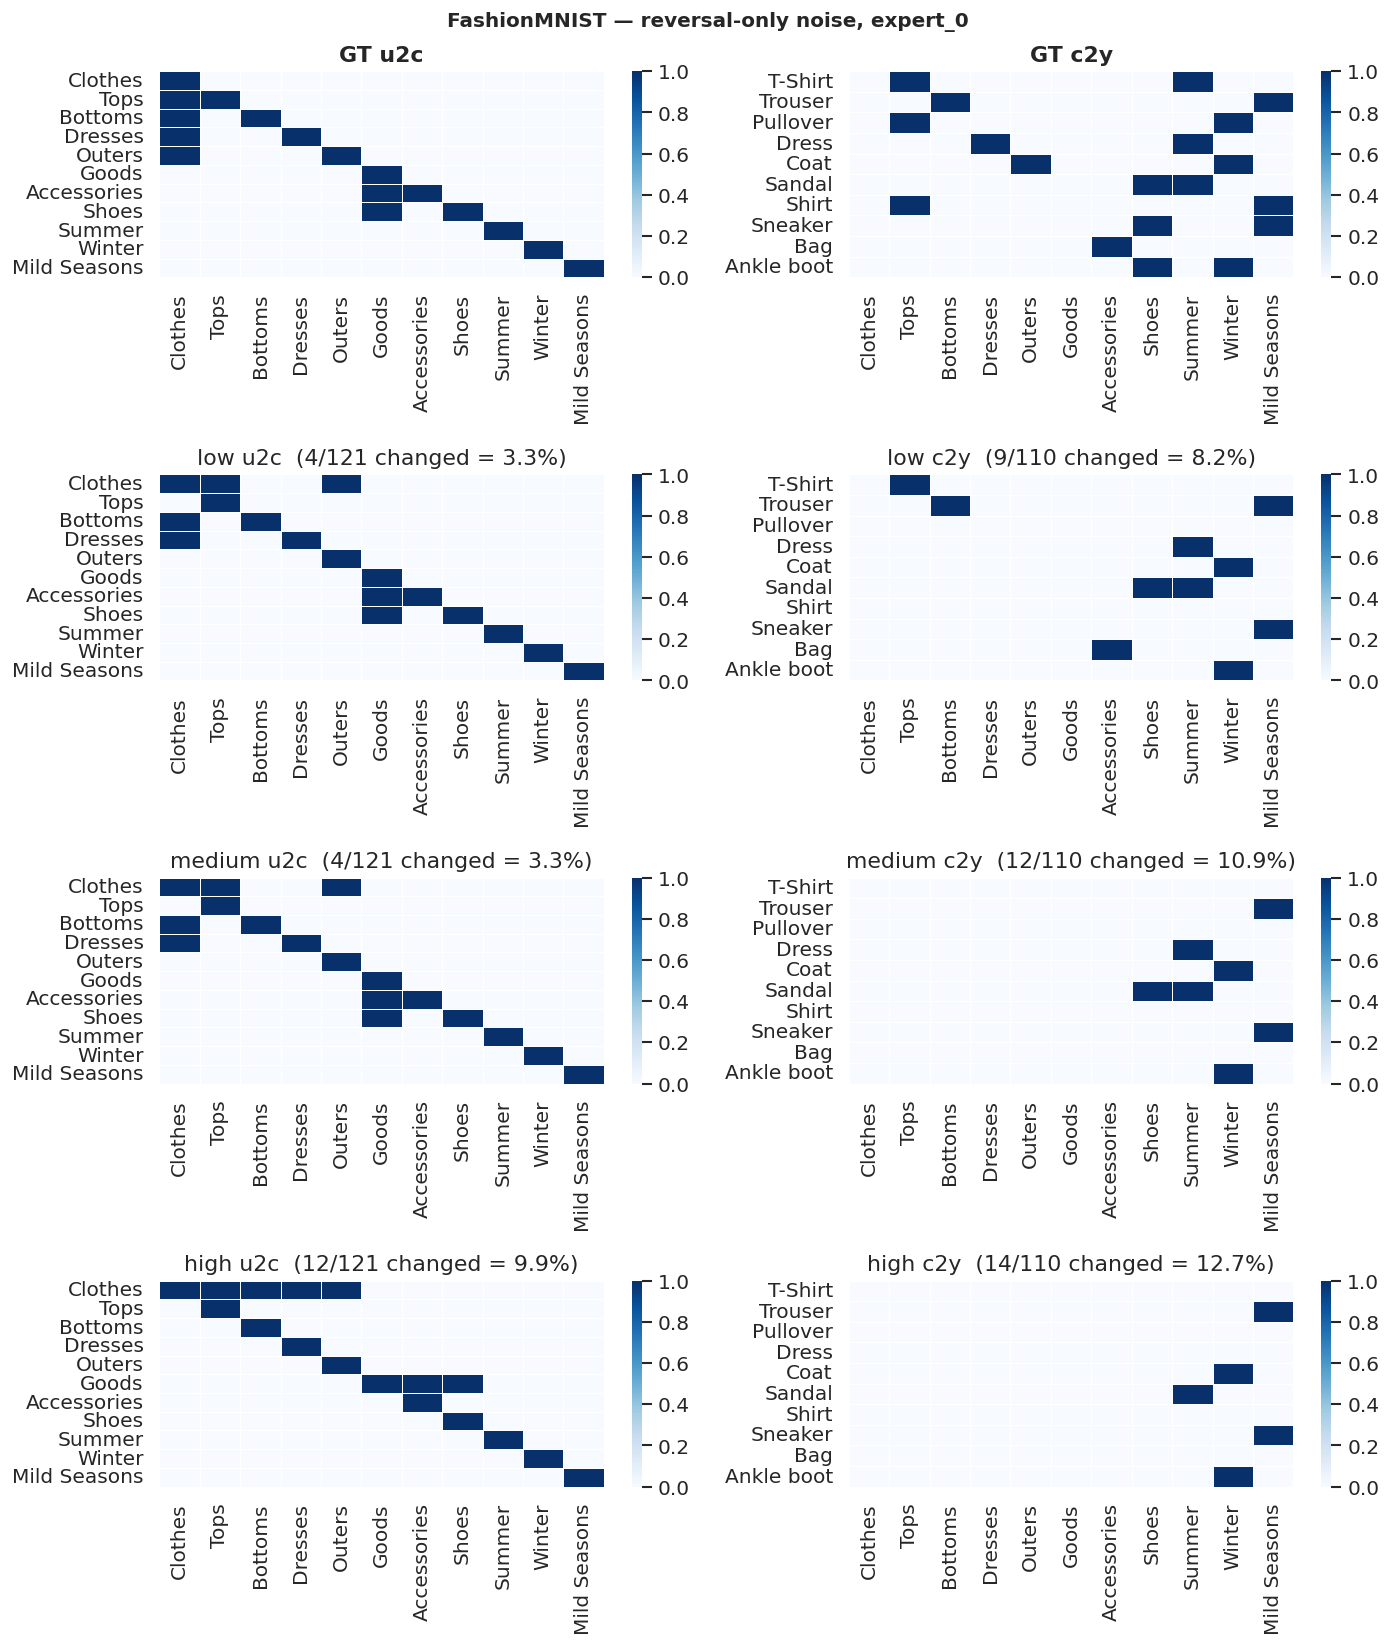

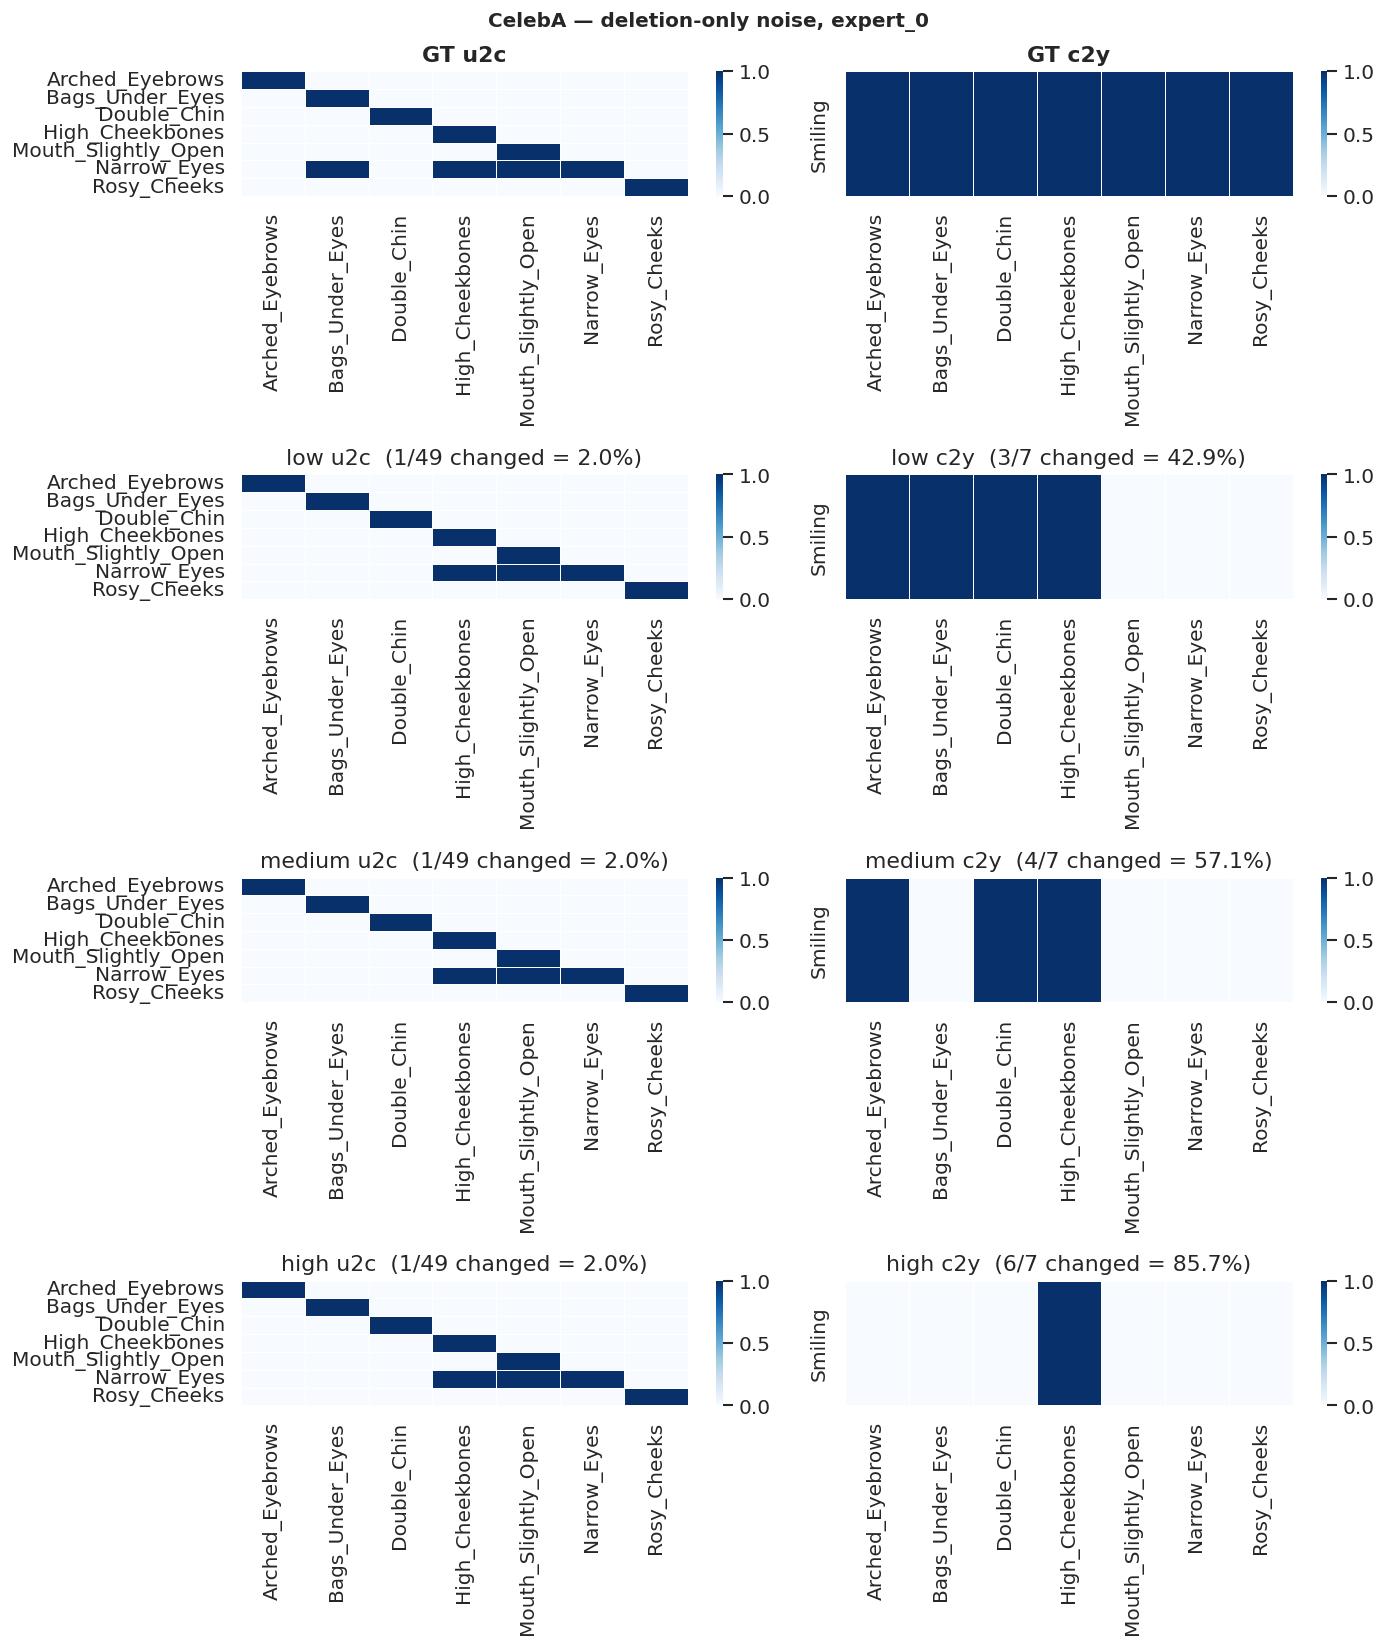

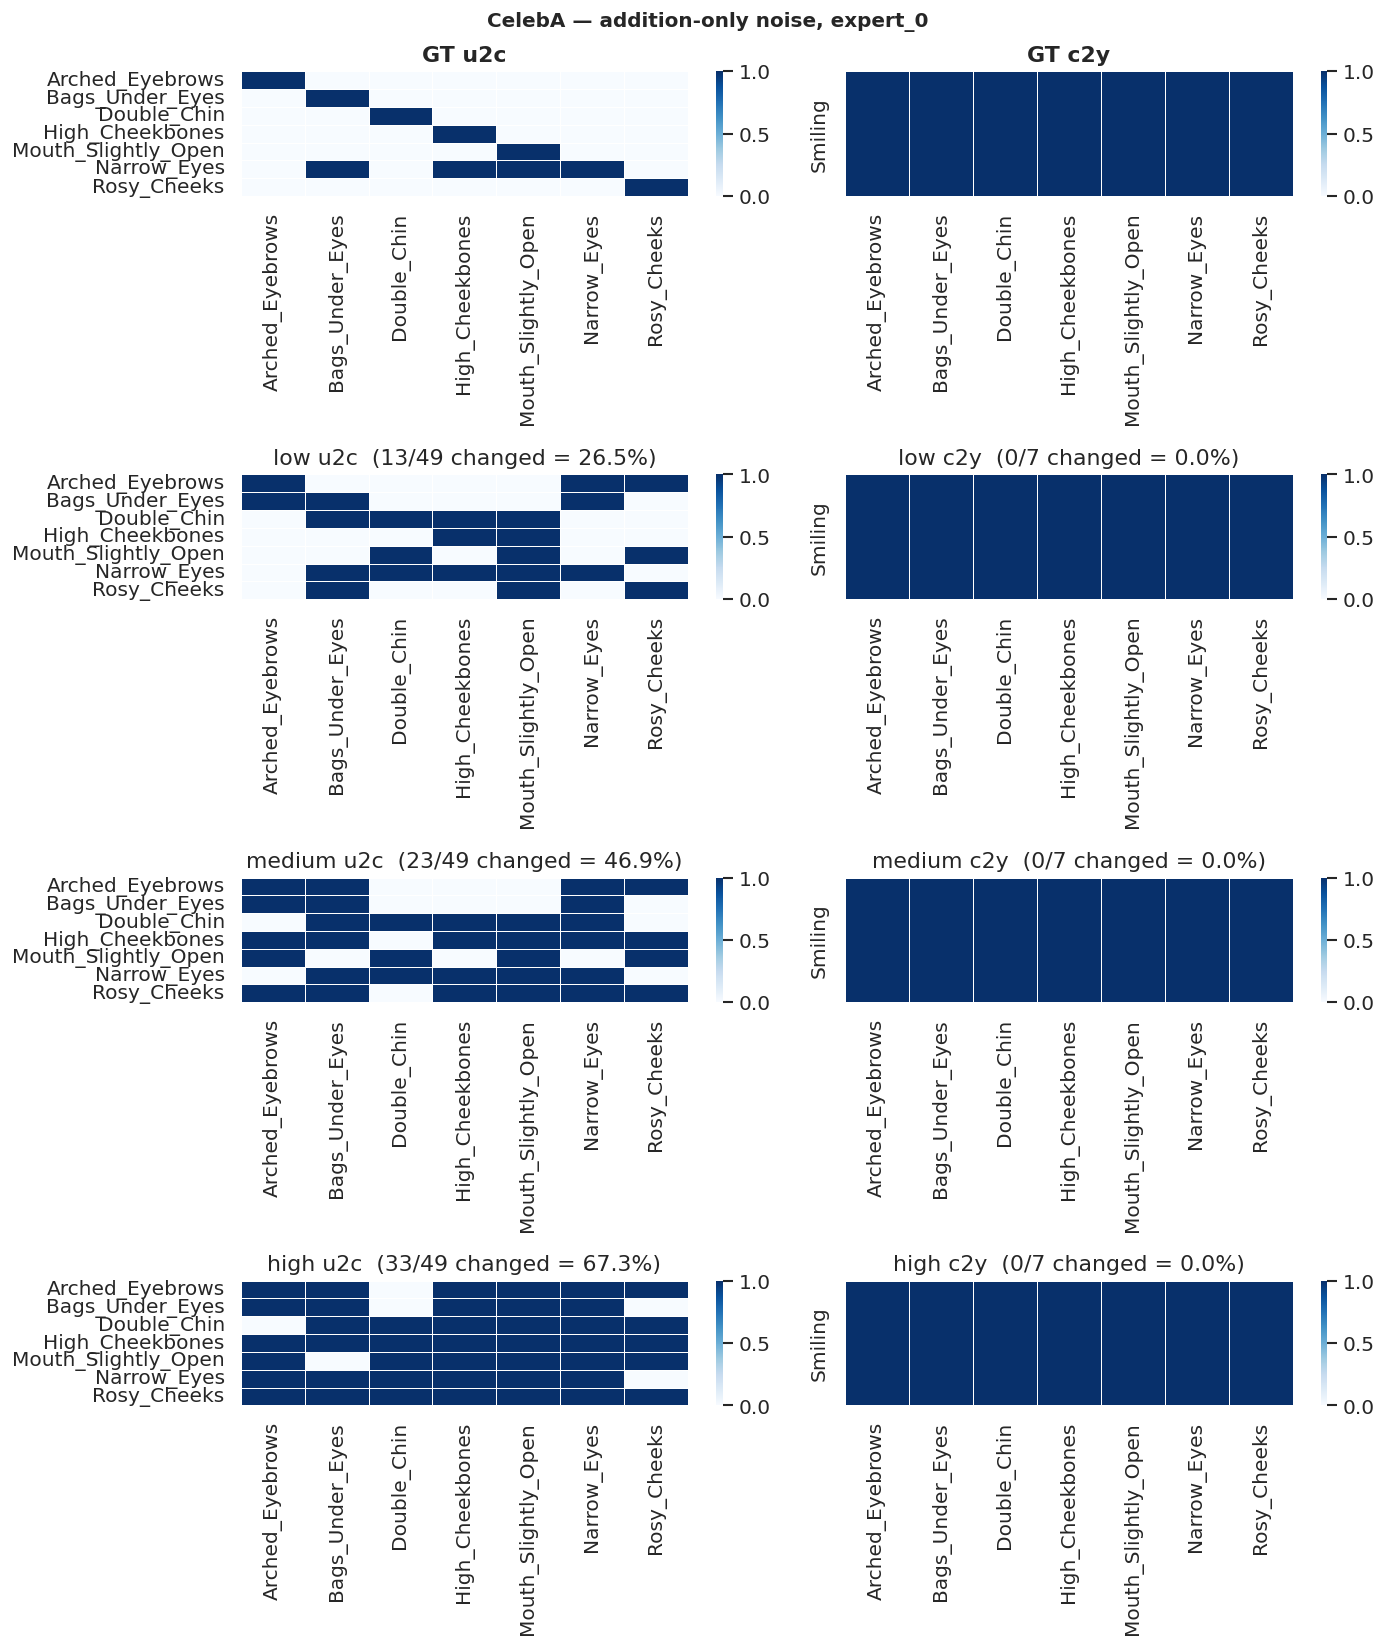

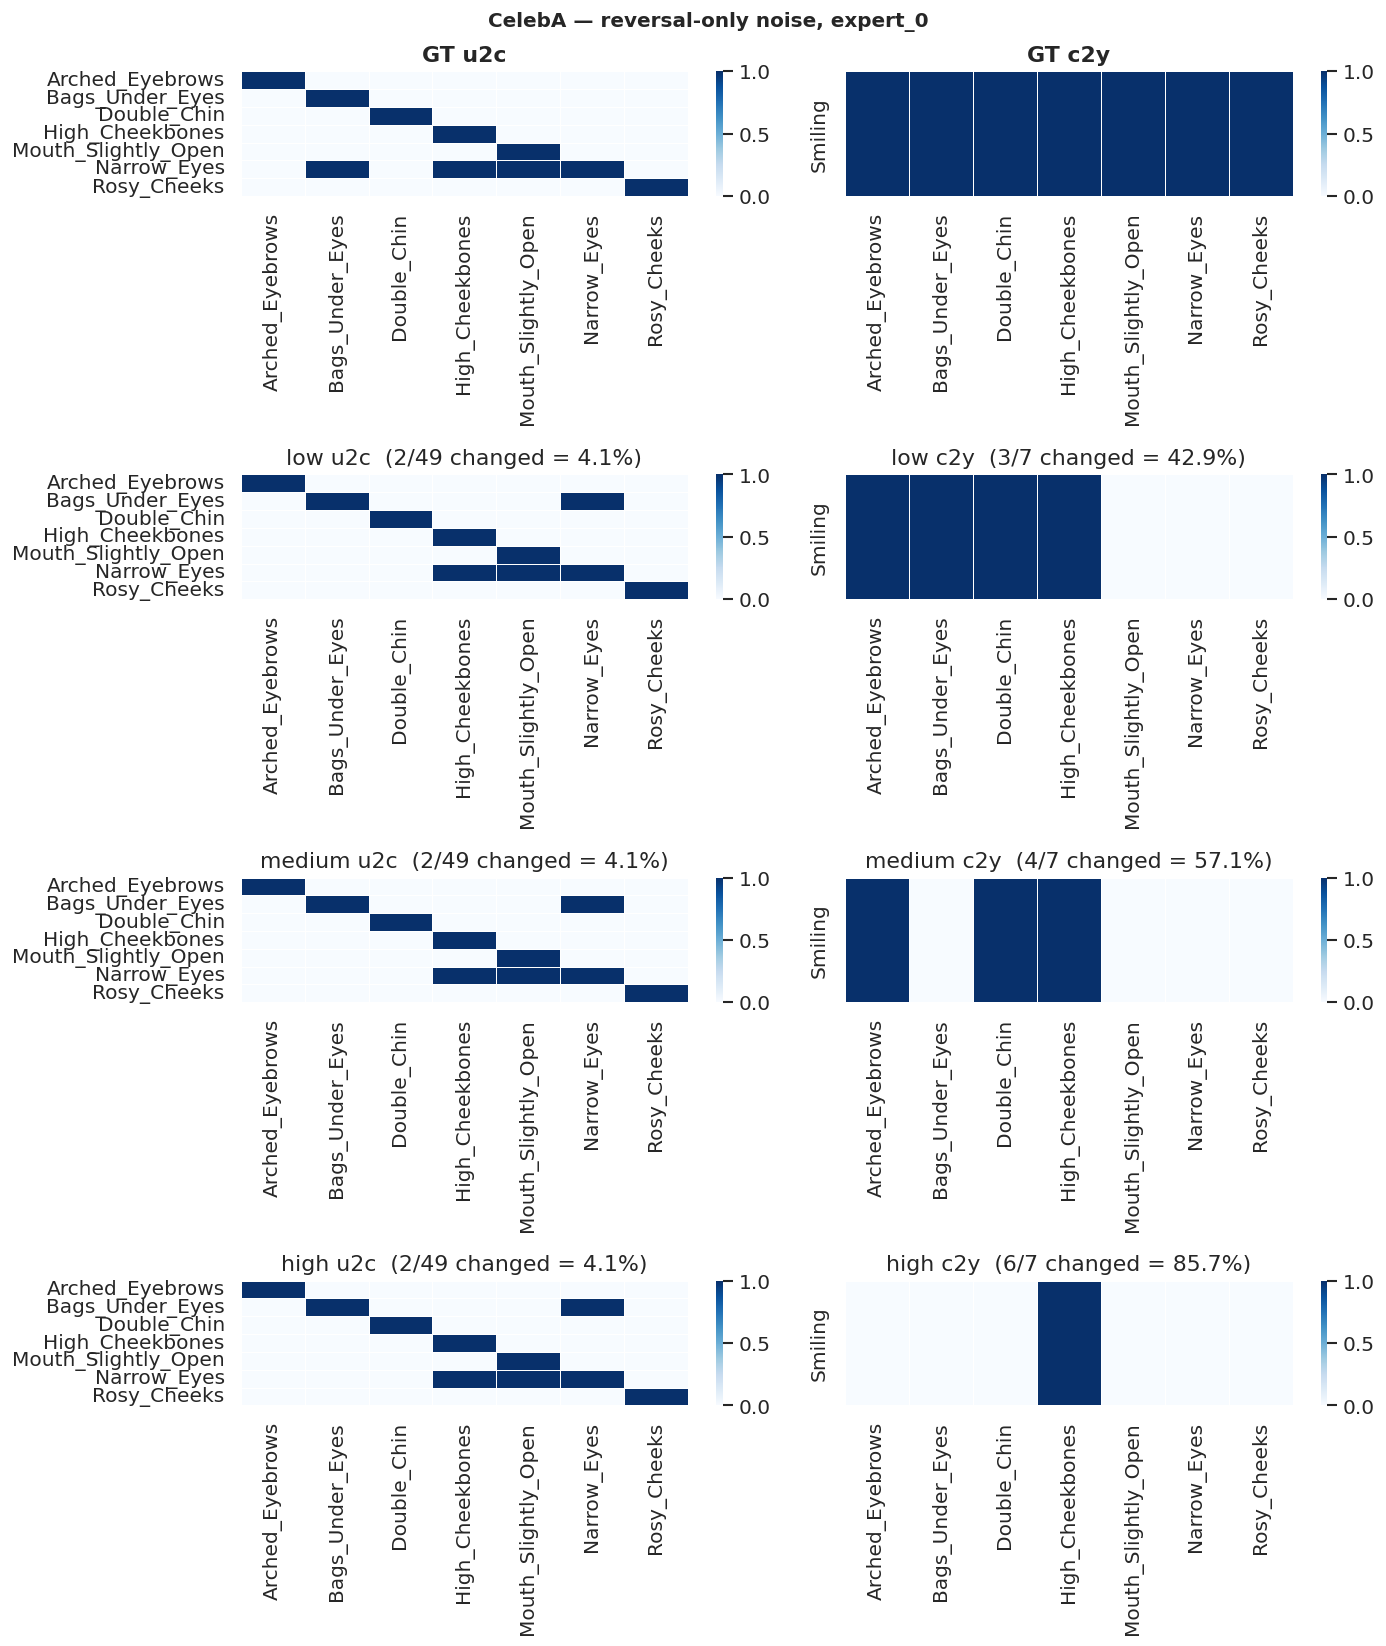

In [3]:
def plot_expert_graphs(dataset_key: str, num_concepts: int, num_classes: int,
                       dag_path: Path, graphs_base: Path):
    """
    For each action × level, load expert_0's u2c and c2y graphs and
    show them alongside the ground truth.
    """
    if not dag_path.exists(): return
    gt_df = pd.read_csv(dag_path, index_col=0)
    concepts = gt_df.columns[:num_concepts].tolist()
    tasks    = gt_df.columns[num_concepts:].tolist()

    gt_u2c = (gt_df.values[:num_concepts, :num_concepts] != 0).astype(float)
    gt_c2y = (gt_df.values[num_concepts:, :num_concepts] != 0).astype(float)

    for action in ACTIONS:
        fig, axes = plt.subplots(len(LEVELS) + 1, 2,
                                 figsize=(12, 3.5 * (len(LEVELS) + 1)))
        fig.suptitle(f"{dataset_key} — {action}-only noise, expert_0",
                     fontsize=12, fontweight="bold")

        # Row 0: ground truth
        for ax, mat, yl, title in [
            (axes[0,0], gt_u2c, concepts, "GT u2c"),
            (axes[0,1], gt_c2y, tasks,    "GT c2y"),
        ]:
            sns.heatmap(mat, ax=ax, cmap="Blues", vmin=0, vmax=1,
                        xticklabels=concepts, yticklabels=yl,
                        linewidths=0.3, annot_kws={"size":7})
            ax.set_title(title, fontweight="bold")

        for row, level in enumerate(LEVELS, start=1):
            graph_dir = graphs_base / dataset_key / "expert_graphs" / "ensemble" / f"{action}_{level}"
            u2c_file = graph_dir / "u2c" / "expert_0.pt"
            c2y_file = graph_dir / "c2y" / "expert_0.pt"

            if not u2c_file.exists():
                axes[row, 0].set_title(f"{level} — not found")
                axes[row, 1].set_visible(False)
                continue

            u2c = torch.load(u2c_file, weights_only=True).float().numpy()
            c2y = torch.load(c2y_file, weights_only=True).float().numpy()[:, :num_concepts]

            for ax, mat, yl, gt_mat, side in [
                (axes[row,0], u2c, concepts, gt_u2c, "u2c"),
                (axes[row,1], c2y, tasks,    gt_c2y, "c2y"),
            ]:
                changed = (mat.astype(bool) != gt_mat.astype(bool)).sum()
                total   = gt_mat.size
                sns.heatmap(mat, ax=ax, cmap="Blues", vmin=0, vmax=1,
                            xticklabels=concepts, yticklabels=yl,
                            linewidths=0.3, annot_kws={"size":7})
                ax.set_title(f"{level} {side}  ({changed}/{total} changed = {100*changed/total:.1f}%)")

        plt.tight_layout()
        plt.show()

plot_expert_graphs("FashionMNIST", 11, 10, DAG_CFMNIST, GRAPHS_ROOT)
plot_expert_graphs("CelebA",       7,  1,  DAG_CELEBA,  GRAPHS_ROOT)

## 3. Load All Ensemble Results

In [4]:
def load_ensemble_results(root: Path) -> pd.DataFrame:
    """
    Scan mCREAM_Ensemble experiment directories and load all per-seed CSVs.
    Parses experiment_name like: ensemble_average_deletion_medium
    """
    rows = []
    for dataset in DATASETS:
        ens_dir = root / dataset / "train_cbm" / "mCREAM_Ensemble"
        if not ens_dir.exists():
            print(f"  [SKIP] {ens_dir}")
            continue
        for exp_dir in sorted(ens_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            exp_name = exp_dir.name  # ensemble_average_deletion_medium
            parts = exp_name.split("_")
            # parse: ensemble_{soft_}{etype}_{action}_{level}
            try:
                # find etype: first part after 'ensemble'
                idx = 1  # skip 'ensemble'
                soft = ""
                if parts[idx] == "soft":
                    soft = "soft_"
                    idx += 1
                etype   = soft + parts[idx];  idx += 1
                action  = parts[idx];          idx += 1
                level   = "_".join(parts[idx:])
            except IndexError:
                etype = action = level = "unknown"

            for seed_dir in sorted(exp_dir.glob("seed_*/lightning_logs/version_*")):
                seed = int(seed_dir.parent.parent.name.split("_")[1])
                for csv_f in sorted(seed_dir.glob("*.csv")):
                    if any(x in csv_f.name for x in
                           ["perc_", "_set_", "intervention_results",
                            "per_expert", "exogenous", "correlation"]):
                        continue
                    try:
                        df = pd.read_csv(csv_f)
                        df["dataset"]     = dataset
                        df["exp_name"]    = exp_name
                        df["etype"]       = etype
                        df["action"]      = action
                        df["noise_level"] = level
                        df["seed"]        = seed
                        rows.append(df)
                    except Exception as e:
                        print(f"  ERR {csv_f}: {e}")

    if not rows:
        print("No ensemble results found. Jobs may still be running.")
        return pd.DataFrame()

    df = pd.concat(rows, ignore_index=True)
    print(f"Loaded {len(df)} rows")
    print(f"  datasets:    {sorted(df['dataset'].unique())}")
    print(f"  etype:       {sorted(df['etype'].unique())}")
    print(f"  actions:     {sorted(df['action'].unique())}")
    print(f"  noise_level: {sorted(df['noise_level'].unique())}")
    return df

ens_df = load_ensemble_results(EXPERIMENTS_ROOT)
ens_df.head(3) if len(ens_df) > 0 else print("Empty — check paths or wait for jobs.")

Loaded 45 rows
  datasets:    ['Complete_Concept_FMNIST']
  etype:       ['average']
  actions:     ['addition', 'deletion', 'reversal']
  noise_level: ['high', 'low', 'medium']


,max_epochs,seed,experiment_name,train_val_time,test_time,num_trainable_parameters,peak_gpu_memory_mb,CPU_time_backprop_True,CPU_memory_backprop_True,GPU_time_backprop_True,...,expert_2_PFI_side_importance,expert_3_CCI,expert_3_PFI_concept_importance,expert_3_PFI_side_importance,expert_4_CCI,expert_4_PFI_concept_importance,expert_4_PFI_side_importance,dataset,exp_name,etype
0,50,1,average_addition_high,6.764593,0.018971,90605,118.965332,0.034285,0.021949,0.030830,...,NaN,0.948562,NaN,NaN,0.923204,NaN,NaN,Complete_Concept_FMNIST,ensemble_average_addition_high,average
1,50,134,average_addition_high,6.663635,0.018760,90605,118.965332,0.034217,0.021270,0.028159,...,NaN,0.949514,NaN,NaN,0.944566,NaN,NaN,Complete_Concept_FMNIST,ensemble_average_addition_high,average
2,50,42,average_addition_high,6.519726,0.017046,90605,116.859375,0.047085,0.021239,0.026695,...,NaN,0.932176,NaN,NaN,0.856990,NaN,NaN,Complete_Concept_FMNIST,ensemble_average_addition_high,average


## 4. Summary Table — Task Accuracy, CCI, PFI, C2Y Baseline

In [5]:
if len(ens_df) == 0:
    print("No data yet.")
else:
    KEY_METRICS = [
        "test_task_accuracy", "test_concept_accuracy",
        "CCI", "PFI_concept_importance", "PFI_side_importance",
        "c2y_baseline_accuracy", "concept_leakage",
    ]
    available = [c for c in KEY_METRICS if c in ens_df.columns]
    GROUP = ["dataset", "action", "noise_level", "etype"]

    means  = ens_df.groupby(GROUP)[available].mean()
    stds   = ens_df.groupby(GROUP)[available].std()
    counts = ens_df.groupby(GROUP)[available[0]].count().rename("n_seeds")

    # Format as mean ± std
    summary = pd.DataFrame(index=means.index)
    summary["n_seeds"] = counts
    for col in available:
        summary[col] = (means[col].map("{:.4f}".format)
                        + " ± " + stds[col].map("{:.4f}".format))

    print("SUMMARY TABLE — mean ± std across seeds")
    print("=" * 80)
    # Show one dataset at a time for readability
    for ds in DATASETS:
        subset = summary.xs(ds, level="dataset") if ds in summary.index.get_level_values("dataset") else None
        if subset is not None and len(subset) > 0:
            print(f"\n{'─'*60}\n  {ds}\n{'─'*60}")
            display(subset)

SUMMARY TABLE — mean ± std across seeds

────────────────────────────────────────────────────────────
  Complete_Concept_FMNIST
────────────────────────────────────────────────────────────


n_seeds test_task_accuracy  \
action   noise_level etype                                 
addition high        average        5    0.9253 ± 0.0006   
         low         average        5    0.9261 ± 0.0009   
         medium      average        5    0.9254 ± 0.0005   
deletion high        average        5    0.9269 ± 0.0006   
         low         average        5    0.9270 ± 0.0009   
         medium      average        5    0.9280 ± 0.0004   
reversal high        average        5    0.9268 ± 0.0010   
         low         average        5    0.9270 ± 0.0006   
         medium      average        5    0.9279 ± 0.0009   

                             test_concept_accuracy              CCI  \
action   noise_level etype                                            
addition high        average       0.9814 ± 0.0005  0.9289 ± 0.0091   
         low         average       0.9818 ± 0.0002  0.7979 ± 0.0059   
         medium      average       0.9817 ± 0.0002  0.8573 ± 0.0148   
deletion high        average       0.9727 ± 0.0004  0.1541 ± 0.0258   
         low         average       0.9819 ± 0.0001  0.5407 ± 0.0233   
         medium      average       0.9734 ± 0.0003  0.2495 ± 0.0252   
reversal high        average       0.9727 ± 0.0005  0.1525 ± 0.0260   
         low         average       0.9821 ± 0.0001  0.5378 ± 0.0235   
         medium      average       0.9734 ± 0.0003  0.2482 ± 0.0288   

                             PFI_concept_importance PFI_side_importance  
action   noise_level etype                                               
addition high        average              nan ± nan           nan ± nan  
         low         average              nan ± nan           nan ± nan  
         medium      average              nan ± nan           nan ± nan  
deletion high        average              nan ± nan           nan ± nan  
         low         average              nan ± nan           nan ± nan  
         medium      average              nan ± nan           nan ± nan  
reversal high        average              nan ± nan           nan ± nan  
         low         average              nan ± nan           nan ± nan  
         medium      average              nan ± nan           nan ± nan

## 5. Per-Expert Accuracy vs Ensemble Accuracy

In [6]:
def load_per_expert_preds(root: Path) -> pd.DataFrame:
    """Load per_expert_predictions.csv files and extract accuracy per expert."""
    rows = []
    for dataset in DATASETS:
        ens_dir = root / dataset / "train_cbm" / "mCREAM_Ensemble"
        if not ens_dir.exists(): continue
        for csv_f in ens_dir.rglob("expert_predictions/per_expert_predictions.csv"):
            try:
                df = pd.read_csv(csv_f)
                # Extract metadata from path
                parts = csv_f.parts
                exp_name = None
                seed = None
                for i, p in enumerate(parts):
                    if p == "mCREAM_Ensemble" and i+1 < len(parts):
                        exp_name = parts[i+1]
                    if p.startswith("seed_"):
                        seed = int(p.split("_")[1])

                if exp_name is None: continue
                p = exp_name.split("_")
                idx = 1
                soft = ""
                if p[idx] == "soft": soft = "soft_"; idx += 1
                etype  = soft + p[idx]; idx += 1
                action = p[idx];        idx += 1
                level  = "_".join(p[idx:])

                # Compute accuracy per expert
                expert_cols = [c for c in df.columns if c.endswith("_correct") and c != "ensemble_correct"]
                for col in expert_cols:
                    m_idx = col.split("_")[1]  # y_0_correct → 0
                    rows.append({
                        "dataset": dataset, "exp_name": exp_name,
                        "etype": etype, "action": action, "noise_level": level,
                        "seed": seed, "expert": int(m_idx),
                        "expert_accuracy": df[col].mean(),
                        "ensemble_accuracy": df["ensemble_correct"].mean(),
                    })
            except Exception as e:
                print(f"ERR {csv_f}: {e}")

    return pd.DataFrame(rows)

expert_acc_df = load_per_expert_preds(EXPERIMENTS_ROOT)
print(f"Loaded {len(expert_acc_df)} expert-level rows")

Loaded 225 expert-level rows


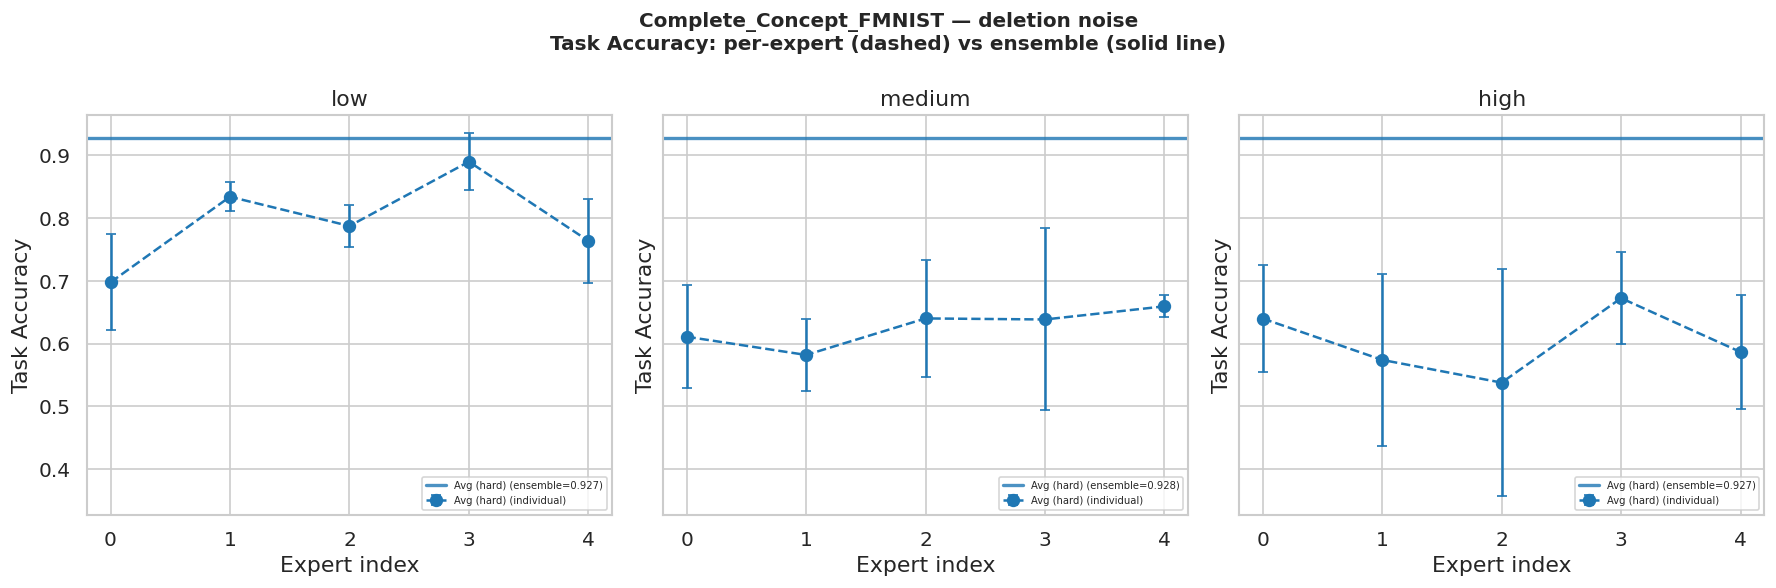

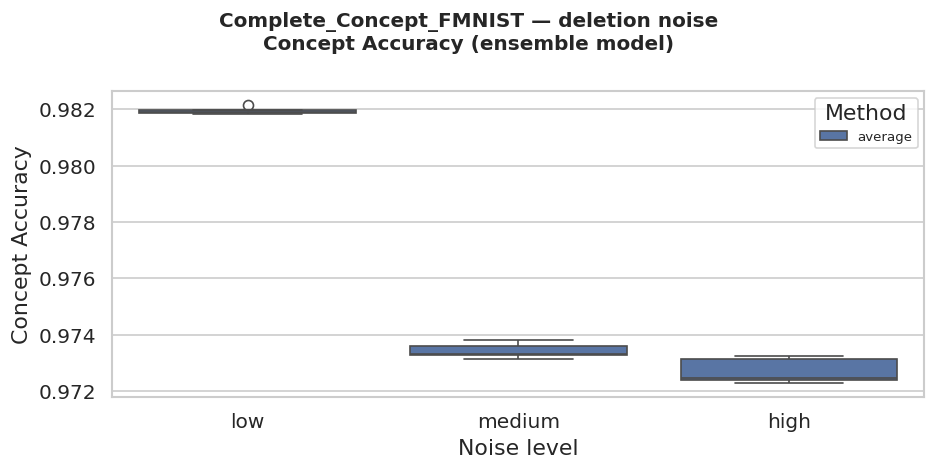

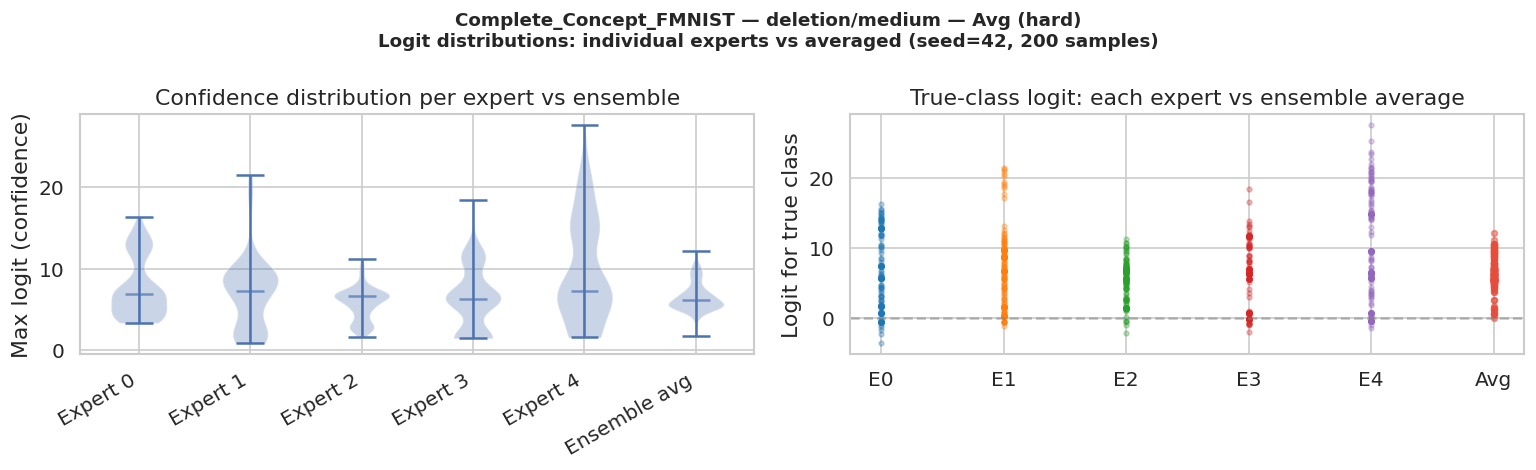

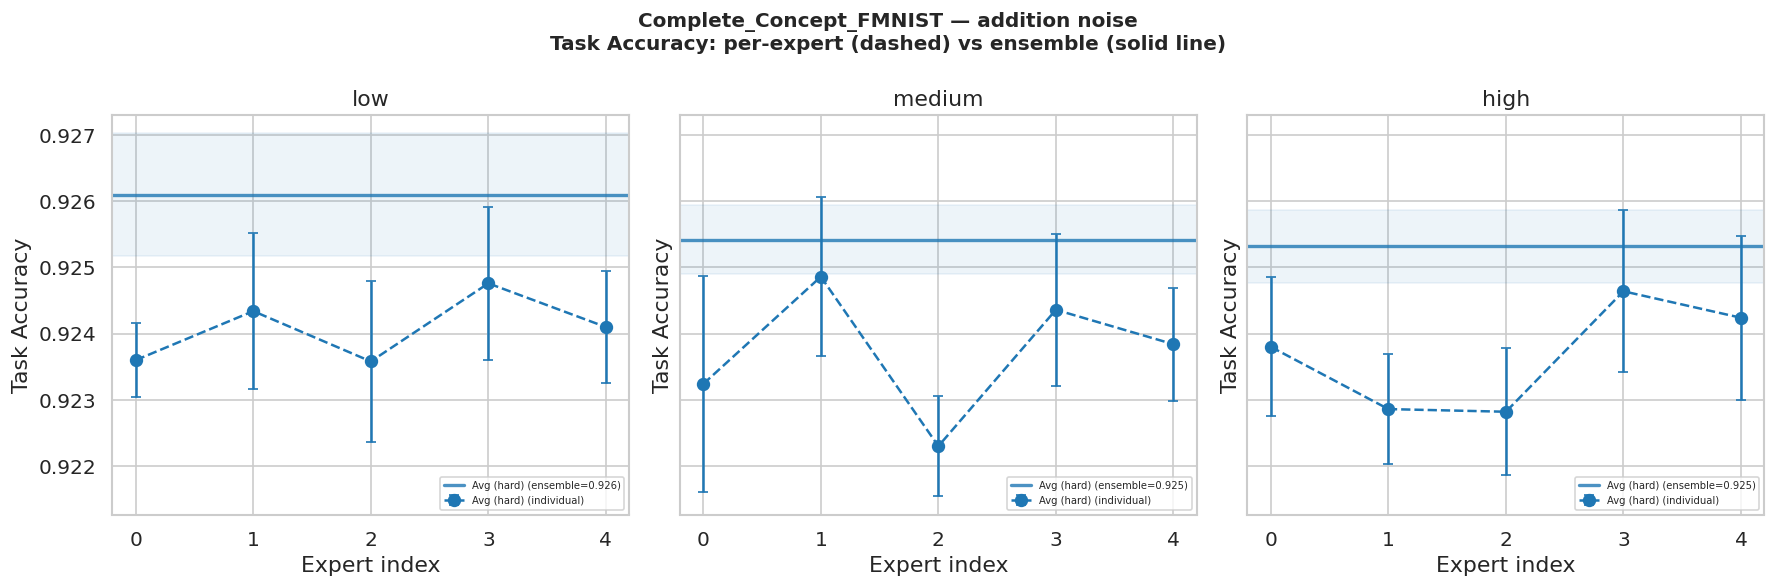

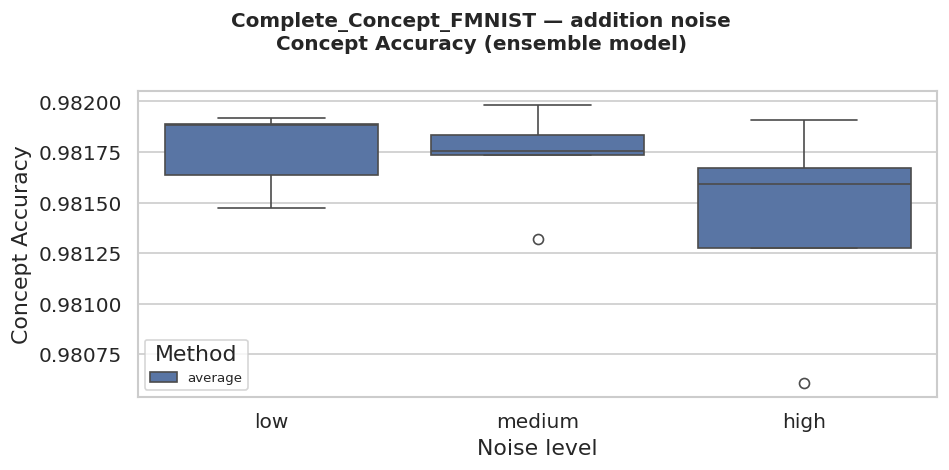

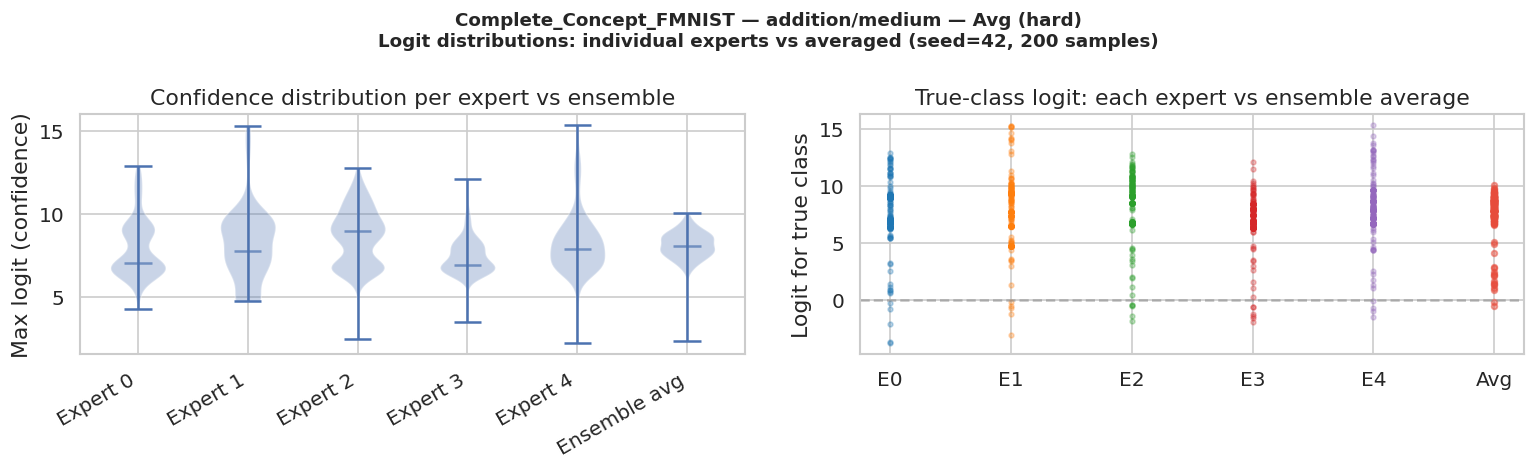

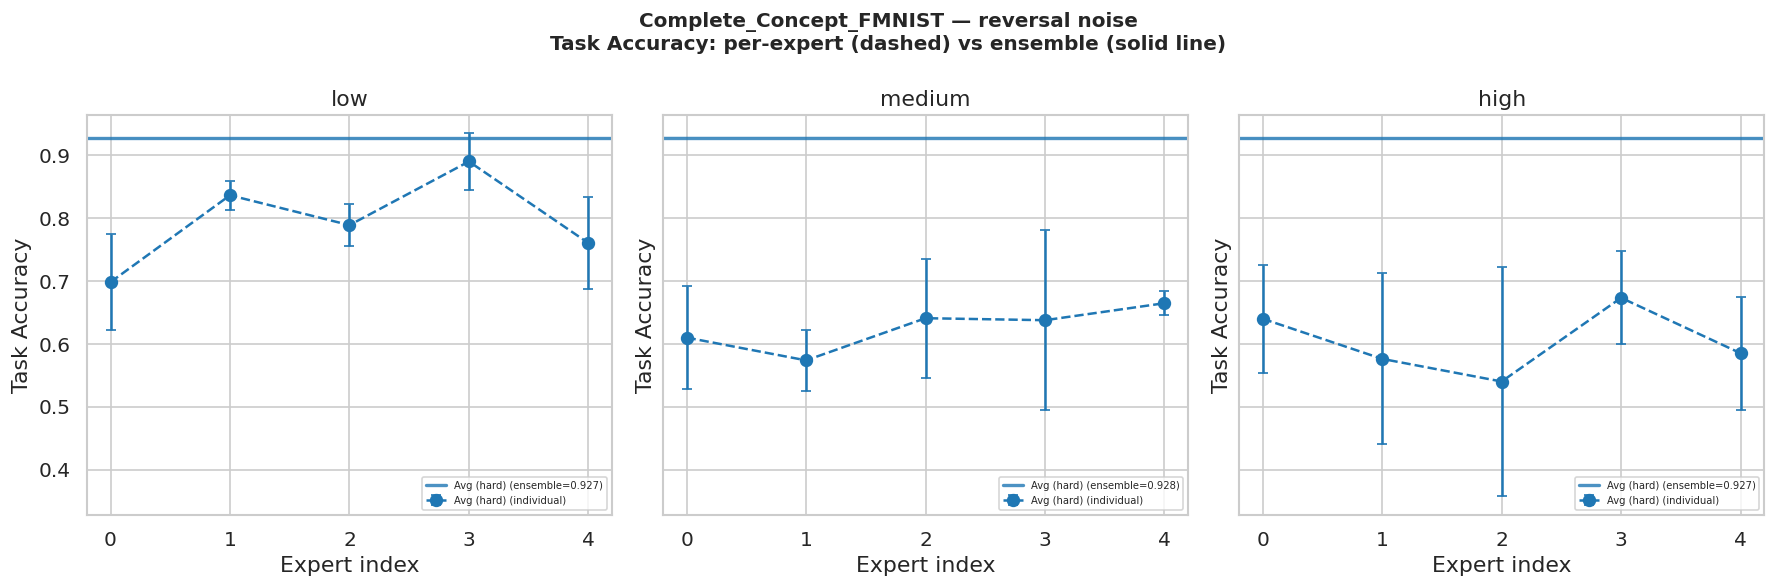

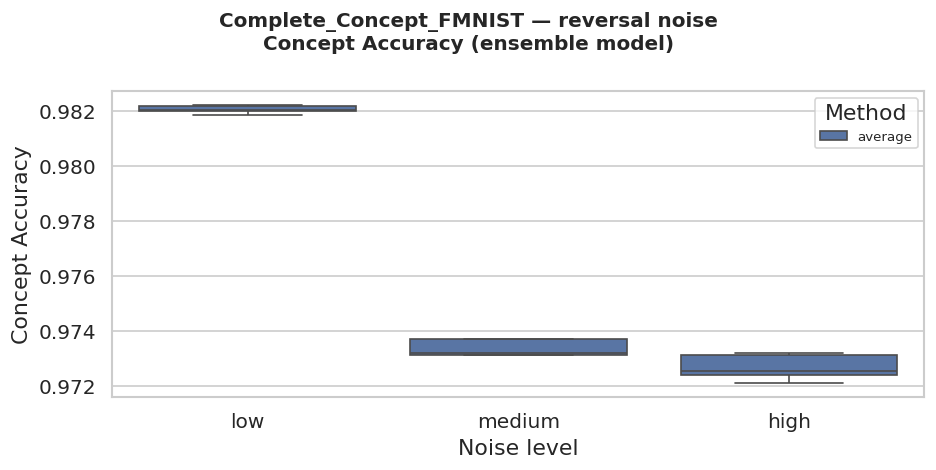

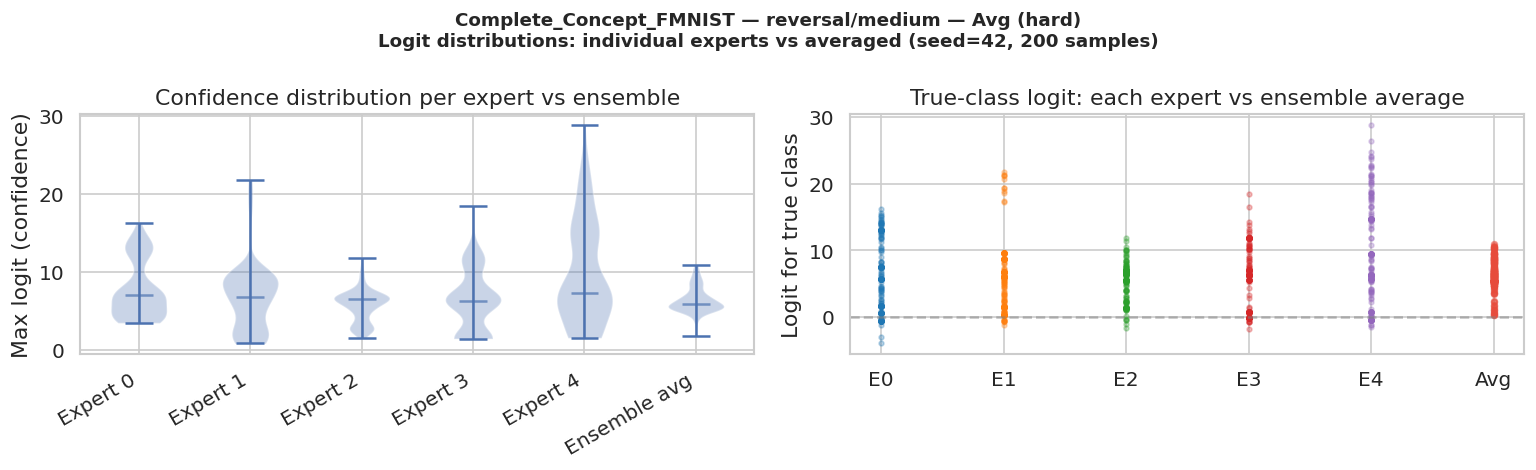

In [7]:
if len(expert_acc_df) == 0:
    print("No per-expert data yet.")
else:
    for dataset in DATASETS:
        ds_df = expert_acc_df[expert_acc_df["dataset"] == dataset]
        if ds_df.empty: continue

        for action in ACTIONS:
            act_df = ds_df[ds_df["action"] == action]
            if act_df.empty: continue

            # ── Figure 1: Task accuracy per expert + ensemble line ──────────
            fig, axes = plt.subplots(1, len(LEVELS), figsize=(5*len(LEVELS), 5), sharey=True)
            fig.suptitle(f"{dataset} — {action} noise\nTask Accuracy: per-expert (dashed) vs ensemble (solid line)",
                         fontsize=12, fontweight="bold")

            for ax, level in zip(axes, LEVELS):
                lv_df = act_df[act_df["noise_level"] == level]
                if lv_df.empty:
                    ax.set_title(f"{level} — no data"); continue

                grp = lv_df.groupby(["etype", "expert"]).agg(
                    acc_mean=("expert_accuracy",  "mean"),
                    acc_std=("expert_accuracy",   "std"),
                    ens_mean=("ensemble_accuracy", "mean"),
                    ens_std=("ensemble_accuracy",  "std"),
                ).reset_index()

                for etype, sub in grp.groupby("etype"):
                    color  = plt.cm.tab10(ETYPES.index(etype) if etype in ETYPES else 0)
                    marker = ETYPE_MARKER.get(etype, "o")
                    label  = ETYPE_LABEL.get(etype, etype)
                    ax.errorbar(sub["expert"], sub["acc_mean"], yerr=sub["acc_std"],
                                label=f"{label} (individual)",
                                marker=marker, color=color, linestyle="--",
                                capsize=3, markersize=7)
                    ens_acc = sub["ens_mean"].mean()
                    ens_std = sub["ens_std"].mean()
                    ax.axhline(ens_acc, color=color, linestyle="-", linewidth=2,
                               alpha=0.8, label=f"{label} (ensemble={ens_acc:.3f})")
                    ax.axhspan(ens_acc - ens_std, ens_acc + ens_std,
                               alpha=0.08, color=color)

                ax.set_title(level)
                ax.set_xlabel("Expert index")
                ax.set_ylabel("Task Accuracy")
                ax.legend(fontsize=6, loc="lower right")

            plt.tight_layout()
            plt.show()

            # ── Figure 2: Concept accuracy per expert (from ens_df summary) ─
            # concept accuracy is stored in ens_df as test_concept_accuracy
            # We show it as bars across noise levels since we don't have
            # per-expert concept accuracy in the predictions CSV.
            if len(ens_df) > 0 and "test_concept_accuracy" in ens_df.columns:
                sub_c = ens_df[
                    (ens_df["dataset"] == dataset) &
                    (ens_df["action"]  == action)
                ]
                if not sub_c.empty:
                    fig2, ax2 = plt.subplots(figsize=(8, 4))
                    fig2.suptitle(f"{dataset} — {action} noise\nConcept Accuracy (ensemble model)",
                                  fontsize=12, fontweight="bold")
                    sns.boxplot(data=sub_c, x="noise_level", y="test_concept_accuracy",
                                hue="etype", order=LEVELS,
                                hue_order=[e for e in ETYPES if e in sub_c["etype"].unique()],
                                ax=ax2)
                    ax2.set_xlabel("Noise level")
                    ax2.set_ylabel("Concept Accuracy")
                    ax2.legend(title="Method", fontsize=8)
                    plt.tight_layout()
                    plt.show()

            # ── Figure 3: Logit distribution — one noise level (medium) ─────
            # Shows how individual expert logits spread and how averaging them
            # produces a sharper, more confident prediction.
            # Load the actual predictions CSV for seed=42, medium noise.
            for etype_show in [e for e in ETYPES if e in act_df["etype"].unique()]:
                exp_name = f"ensemble_{etype_show}_{action}_medium"
                pred_csv = (EXPERIMENTS_ROOT / dataset / "train_cbm" / "mCREAM_Ensemble"
                            / exp_name / "seed_42" / "lightning_logs" / "version_0"
                            / "expert_predictions" / "per_expert_predictions.csv")
                if not pred_csv.exists():
                    continue

                pred_df = pd.read_csv(pred_csv)
                # Find number of experts and classes from column names
                logit_cols_0 = [c for c in pred_df.columns if c.startswith("y_0_logit_")]
                n_classes = len(logit_cols_0)
                n_experts = len([c for c in pred_df.columns if c.endswith("_pred")
                                  and c.startswith("y_")])

                if n_classes == 0 or n_experts == 0:
                    continue

                # Pick a random sample of 200 for visibility
                sample = pred_df.sample(min(200, len(pred_df)), random_state=42)

                # Build logit arrays: [M, N_samples, T]
                expert_logits = []
                for m in range(n_experts):
                    cols = [f"y_{m}_logit_{t}" for t in range(n_classes)]
                    expert_logits.append(sample[cols].values)  # [N, T]
                expert_logits = np.stack(expert_logits, axis=0)  # [M, N, T]

                # Average logits
                avg_logits = expert_logits.mean(axis=0)  # [N, T]

                # Plot: for each sample, show the max logit (confidence) per expert vs avg
                fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4))
                fig3.suptitle(
                    f"{dataset} — {action}/medium — {ETYPE_LABEL.get(etype_show, etype_show)}\n"
                    f"Logit distributions: individual experts vs averaged (seed=42, 200 samples)",
                    fontsize=11, fontweight="bold"
                )

                # Left: violin plot of max logit (confidence) per expert vs avg
                ax_v = axes3[0]
                data_v = []
                labels_v = []
                for m in range(n_experts):
                    max_logits = expert_logits[m].max(axis=1)
                    data_v.append(max_logits)
                    labels_v.append(f"Expert {m}")
                data_v.append(avg_logits.max(axis=1))
                labels_v.append("Ensemble avg")

                ax_v.violinplot(data_v, positions=range(len(data_v)),
                                showmedians=True, showextrema=True)
                ax_v.set_xticks(range(len(labels_v)))
                ax_v.set_xticklabels(labels_v, rotation=30, ha="right")
                ax_v.set_ylabel("Max logit (confidence)")
                ax_v.set_title("Confidence distribution per expert vs ensemble")
                # Color the last violin (ensemble) differently
                parts = ax_v.collections
                if parts:
                    parts[-1].set_facecolor("#e74c3c")
                    parts[-1].set_alpha(0.7)

                # Right: for the true class, show each expert's logit vs avg logit
                ax_r = axes3[1]
                true_classes = sample["y_true"].values
                for m in range(n_experts):
                    true_logits_m = expert_logits[m][np.arange(len(sample)), true_classes.astype(int)]
                    ax_r.scatter(np.full(len(sample), m), true_logits_m,
                                 alpha=0.3, s=8, color=plt.cm.tab10(m))
                # Ensemble avg logit for true class
                true_logits_avg = avg_logits[np.arange(len(sample)), true_classes.astype(int)]
                ax_r.scatter(np.full(len(sample), n_experts), true_logits_avg,
                             alpha=0.5, s=12, color="#e74c3c", label="Ensemble avg")
                ax_r.set_xticks(range(n_experts + 1))
                ax_r.set_xticklabels([f"E{m}" for m in range(n_experts)] + ["Avg"],
                                     rotation=0)
                ax_r.set_ylabel("Logit for true class")
                ax_r.set_title("True-class logit: each expert vs ensemble average")
                ax_r.axhline(0, color="gray", linestyle="--", alpha=0.5)

                plt.tight_layout()
                plt.show()
                break  # show only first available etype to avoid repetition

## 6. Intervention Curves

In [8]:
def load_ensemble_interventions(root: Path) -> pd.DataFrame:
    rows = []
    for dataset in DATASETS:
        ens_dir = root / dataset / "train_cbm" / "mCREAM_Ensemble"
        if not ens_dir.exists(): continue
        for csv_f in ens_dir.rglob("intervention_results.csv"):
            try:
                df = pd.read_csv(csv_f)
                parts = csv_f.parts
                exp_name = seed = None
                for i, p in enumerate(parts):
                    if p == "mCREAM_Ensemble" and i+1 < len(parts): exp_name = parts[i+1]
                    if p.startswith("seed_"): seed = int(p.split("_")[1])
                if exp_name is None: continue
                p = exp_name.split("_")
                idx = 1
                soft = ""
                if p[idx] == "soft": soft = "soft_"; idx += 1
                etype  = soft + p[idx]; idx += 1
                action = p[idx];        idx += 1
                level  = "_".join(p[idx:])
                df["dataset"] = dataset; df["etype"] = etype
                df["action"]  = action;  df["noise_level"] = level
                df["seed"]    = seed
                rows.append(df)
            except Exception as e:
                print(f"ERR {csv_f}: {e}")
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

interv_df = load_ensemble_interventions(EXPERIMENTS_ROOT)
print(f"Loaded {len(interv_df)} intervention rows")

Loaded 540 intervention rows


In [11]:
def load_per_expert_pfi_cci(root: Path) -> pd.DataFrame:
    """
    Load per_expert_pfi_cci.csv files.
    Columns: expert, CCI, PFI_concept_importance, PFI_side_importance
    One row per expert per seed.
    """
    rows = []
    for dataset in DATASETS:
        ens_dir = root / dataset / "train_cbm" / "mCREAM_Ensemble"
        if not ens_dir.exists(): continue
        for csv_f in ens_dir.rglob("per_expert_pfi_cci.csv"):
            try:
                df = pd.read_csv(csv_f)
                parts = csv_f.parts
                exp_name = seed = None
                for i, p in enumerate(parts):
                    if p == "mCREAM_Ensemble" and i+1 < len(parts): exp_name = parts[i+1]
                    if p.startswith("seed_"): seed = int(p.split("_")[1])
                if exp_name is None: continue
                p = exp_name.split("_")
                idx = 1
                soft = ""
                if p[idx] == "soft": soft = "soft_"; idx += 1
                etype  = soft + p[idx]; idx += 1
                action = p[idx];        idx += 1
                level  = "_".join(p[idx:])
                df["dataset"] = dataset; df["etype"]       = etype
                df["action"]  = action;  df["noise_level"] = level
                df["seed"]    = seed
                rows.append(df)
            except Exception as e:
                print(f"ERR {csv_f}: {e}")
    if not rows:
        print("No per-expert PFI/CCI data yet.")
        return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f"Loaded {len(df)} per-expert CCI rows")
    print(f"  experts: {sorted(df['expert'].unique())}")
    return df

per_expert_cci_df = load_per_expert_pfi_cci(EXPERIMENTS_ROOT)
per_expert_cci_df if len(per_expert_cci_df) > 0 else None

Loaded 225 per-expert CCI rows
  experts: [0, 1, 2, 3, 4]


,expert,PFI_concept_importance,PFI_side_importance,CCI,dataset,etype,action,noise_level,seed
0,0,NaN,NaN,0.887826,Complete_Concept_FMNIST,average,addition,medium,1
1,1,NaN,NaN,0.858765,Complete_Concept_FMNIST,average,addition,medium,1
2,2,NaN,NaN,0.907449,Complete_Concept_FMNIST,average,addition,medium,1
3,3,NaN,NaN,0.828484,Complete_Concept_FMNIST,average,addition,medium,1
4,4,NaN,NaN,0.839135,Complete_Concept_FMNIST,average,addition,medium,1
...,...,...,...,...,...,...,...,...,...
220,0,NaN,NaN,0.782605,Complete_Concept_FMNIST,average,addition,low,7
221,1,NaN,NaN,0.852462,Complete_Concept_FMNIST,average,addition,low,7
222,2,NaN,NaN,0.775823,Complete_Concept_FMNIST,average,addition,low,7
223,3,NaN,NaN,0.811087,Complete_Concept_FMNIST,average,addition,low,7


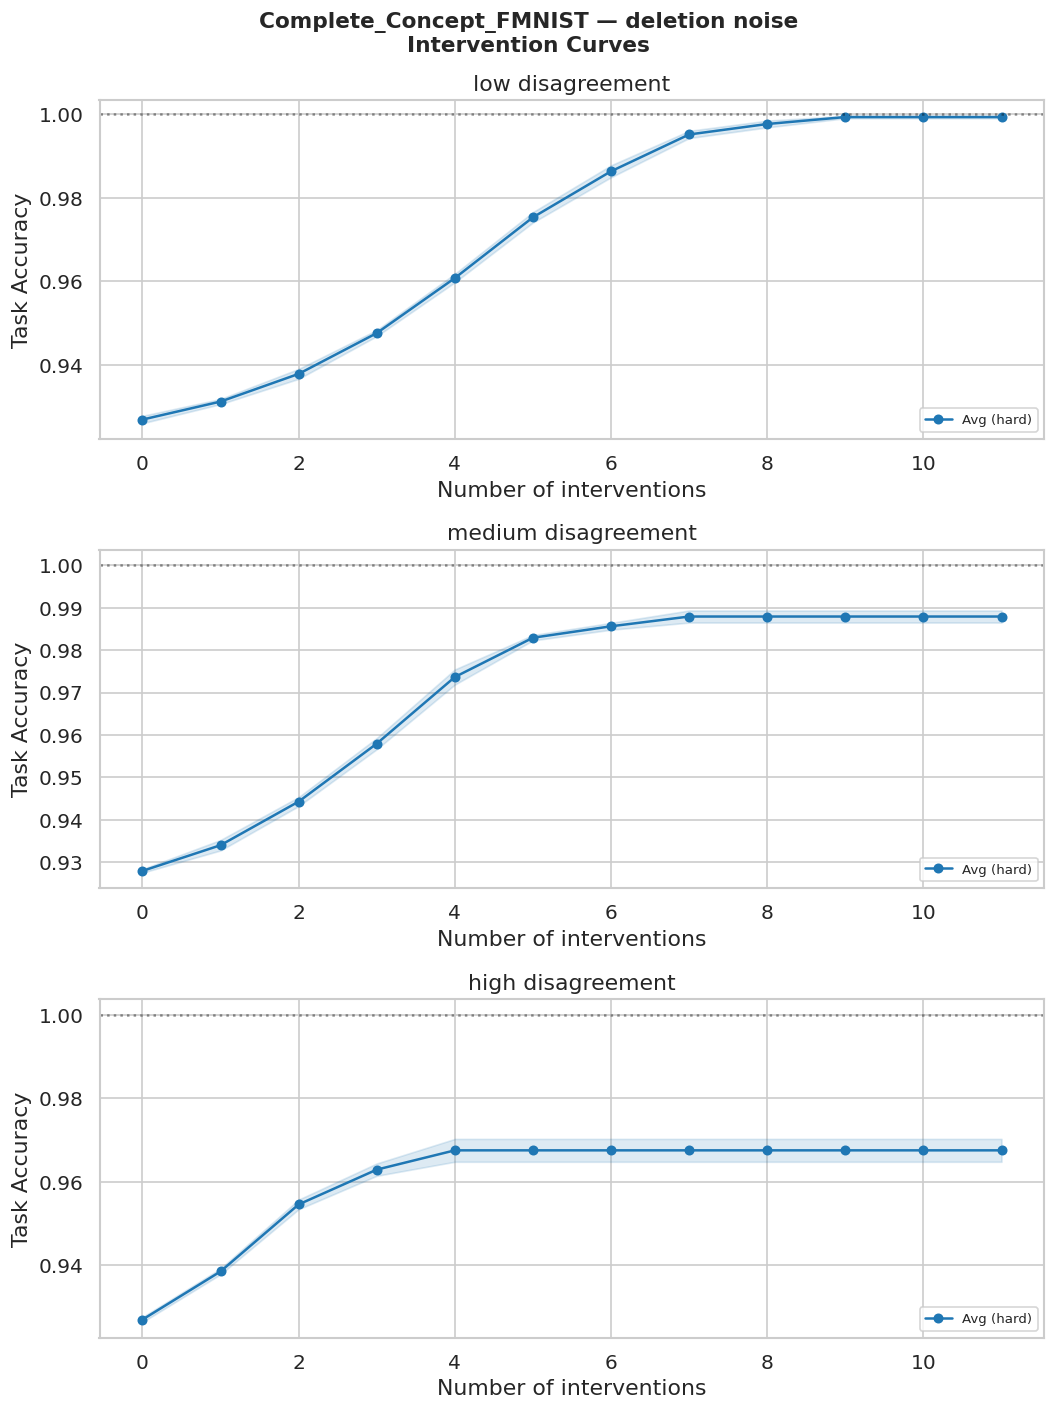

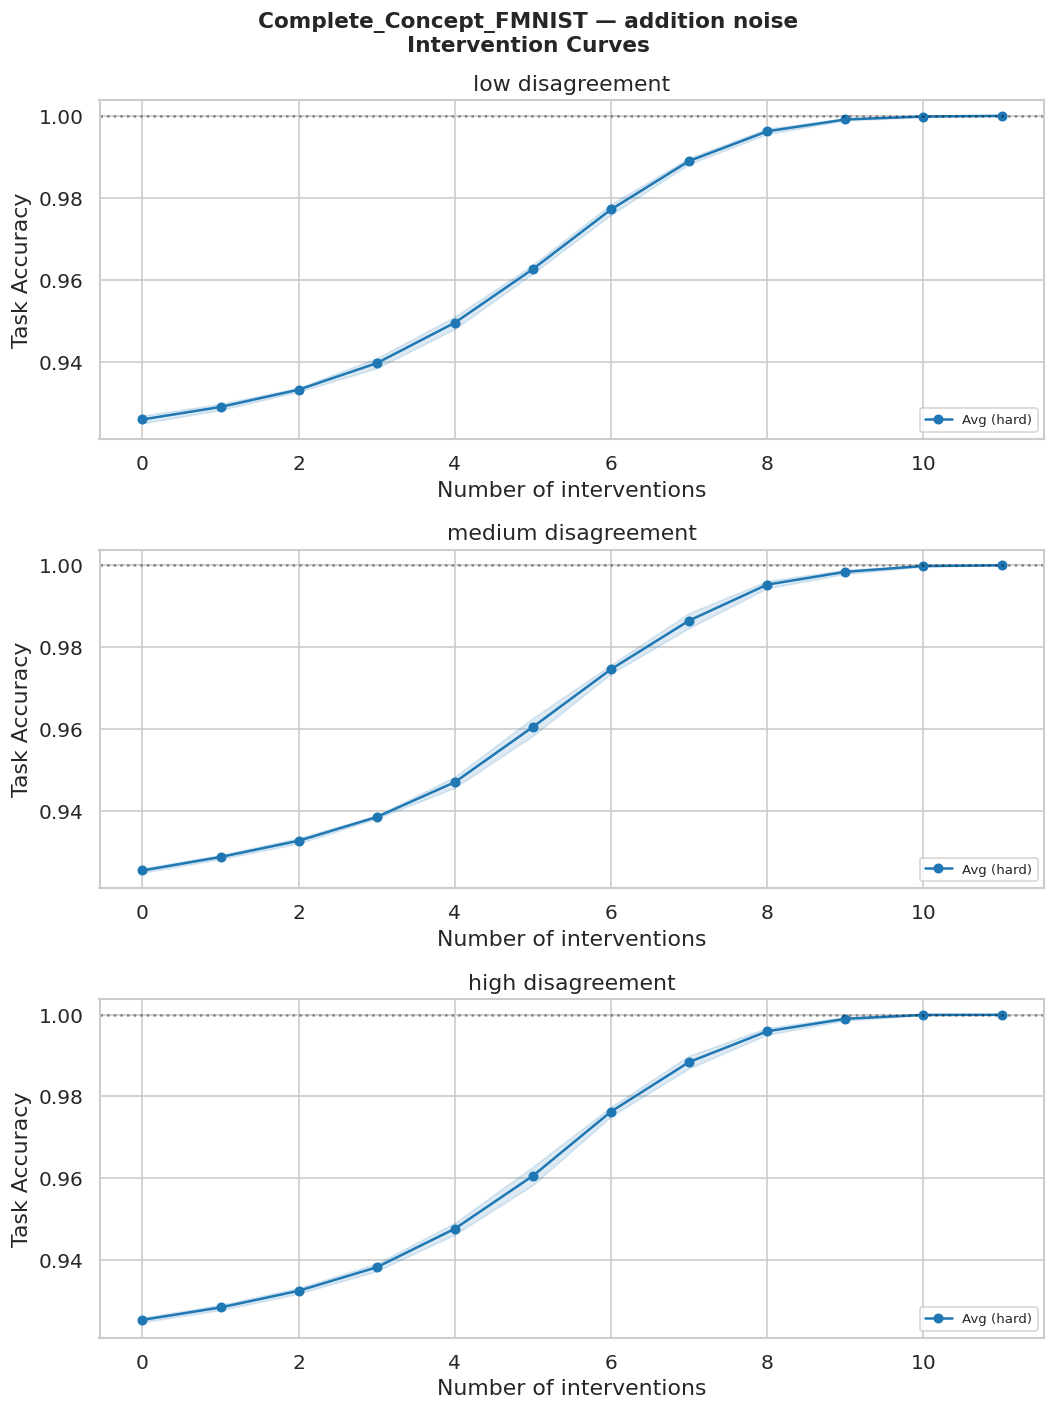

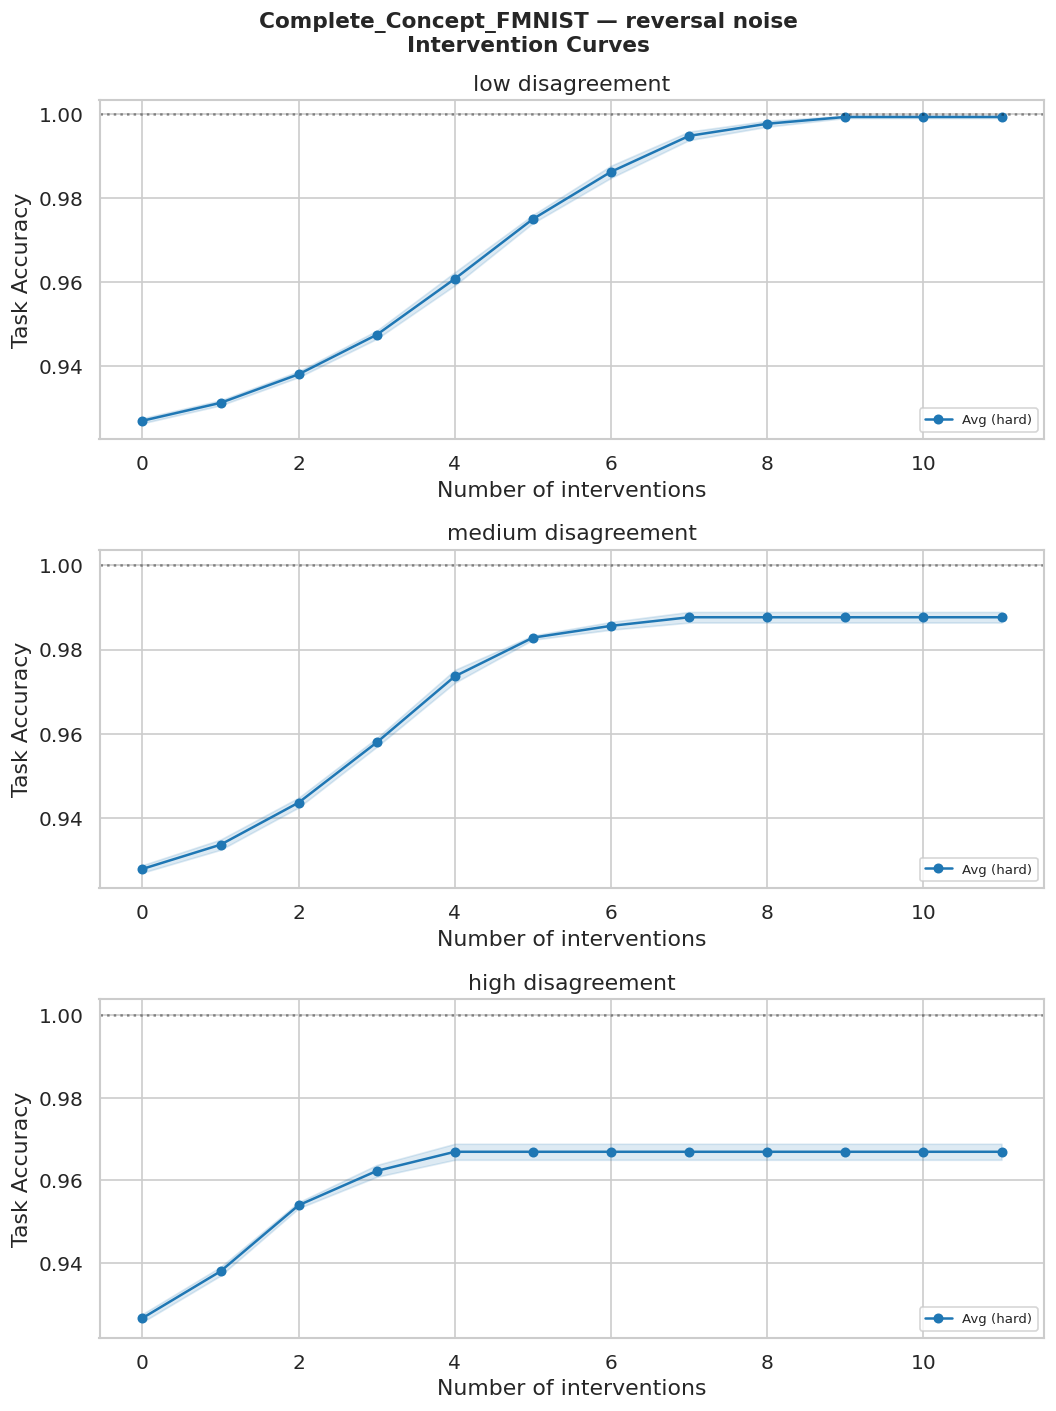

In [12]:
if len(interv_df) == 0:
    print("No intervention data yet.")
else:
    # Intervention curves: one figure per dataset × action
    # Rows = noise levels, cols = ensemble types
    # Style matches the CREAM paper (Figure 6)
    for dataset in DATASETS:
        for action in ACTIONS:
            sub = interv_df[(interv_df["dataset"] == dataset) &
                            (interv_df["action"]  == action)]
            if sub.empty: continue

            n_levels = len(LEVELS)
            n_etypes = len(ETYPES)
            fig, axes = plt.subplots(n_levels, 1,
                                     figsize=(9, 4 * n_levels), sharex=False)
            if n_levels == 1: axes = [axes]

            fig.suptitle(f"{dataset} — {action} noise\nIntervention Curves",
                         fontsize=13, fontweight="bold")

            for ax, level in zip(axes, LEVELS):
                lv = sub[sub["noise_level"] == level]
                if lv.empty:
                    ax.set_title(f"{level} — no data"); continue

                agg = (lv.groupby(["etype", "num_interventions"])["test_task_accuracy"]
                         .agg(["mean", "std"])
                         .reset_index())

                for i_et, etype in enumerate(ETYPES):
                    et_data = agg[agg["etype"] == etype]
                    if et_data.empty: continue
                    color  = plt.cm.tab10(i_et)
                    marker = ETYPE_MARKER.get(etype, "o")
                    ax.plot(et_data["num_interventions"], et_data["mean"],
                            label=ETYPE_LABEL.get(etype, etype),
                            color=color, marker=marker, markersize=5)
                    ax.fill_between(et_data["num_interventions"],
                                   et_data["mean"] - et_data["std"],
                                   et_data["mean"] + et_data["std"],
                                   alpha=0.15, color=color)

                ax.set_title(f"{level} disagreement")
                ax.set_xlabel("Number of interventions")
                ax.set_ylabel("Task Accuracy")
                ax.legend(fontsize=8, loc="lower right")
                ax.axhline(1.0, color="black", linestyle=":", alpha=0.4)

            plt.tight_layout()
            plt.savefig(f"ensemble_interventions_{dataset}_{action}.png",
                        dpi=150, bbox_inches="tight")
            plt.show()

## 6a. Spurious vs Missing Edges per Expert

**Spurious edges** (addition noise): edges in expert graph but NOT in ground truth.
These are false connections — the model learns spurious concept→task paths.
More spurious edges → intervention reaches more tasks per concept → steeper curve.

**Missing edges** (deletion noise): edges in ground truth but NOT in expert graph.
These are broken connections — the model cannot use those concept→task paths.
More missing edges → intervention is less effective → flatter curve.

This plot verifies your professor's hypothesis directly.

In [ ]:
if len(ens_df) == 0:
    print("No data yet.")
else:
    # Extract per-expert spurious and missing edge counts from ens_df
    # Columns: expert_m_u2c_spurious_edges, expert_m_u2c_missing_edges, etc.

    spurious_cols_c2y = [c for c in ens_df.columns if "c2y_spurious" in c]
    missing_cols_c2y  = [c for c in ens_df.columns if "c2y_missing"  in c]

    if not spurious_cols_c2y:
        print("Spurious/missing edge columns not found — re-run jobs with updated code.")
    else:
        for dataset in DATASETS:
            ds = ens_df[ens_df["dataset"] == dataset].copy()
            if ds.empty: continue

            # Melt to long form: one row per (seed, action, noise_level, expert)
            rows_sp = []
            n_experts_found = max(
                int(c.split("_")[1]) for c in spurious_cols_c2y
            ) + 1

            for _, row in ds.iterrows():
                for m in range(n_experts_found):
                    sp_col = f"expert_{m}_c2y_spurious_edges"
                    ms_col = f"expert_{m}_c2y_missing_edges"
                    gt_col = f"expert_{m}_c2y_gt_edges"
                    if sp_col not in row.index: continue
                    rows_sp.append({
                        "action":      row["action"],
                        "noise_level": row["noise_level"],
                        "etype":       row["etype"],
                        "seed":        row.get("seed", 0),
                        "expert":      m,
                        "spurious":    row[sp_col],
                        "missing":     row[ms_col],
                        "gt_edges":    row.get(gt_col, 29),
                    })

            if not rows_sp:
                print(f"  No edge data for {dataset}"); continue

            edges_df = pd.DataFrame(rows_sp)

            # ── Plot 1: Spurious vs Missing per action × noise level ─────────
            fig, axes = plt.subplots(len(LEVELS), len(ACTIONS),
                                     figsize=(5*len(ACTIONS), 4*len(LEVELS)),
                                     sharey=False)
            fig.suptitle(f"{dataset}\nSpurious (added) vs Missing (deleted) c2y edges per expert",
                         fontsize=12, fontweight="bold")

            for row_i, level in enumerate(LEVELS):
                for col_i, action in enumerate(ACTIONS):
                    ax = axes[row_i, col_i] if len(LEVELS) > 1 else axes[col_i]
                    sub = edges_df[
                        (edges_df["noise_level"] == level) &
                        (edges_df["action"]  == action)
                    ]
                    if sub.empty:
                        ax.set_title(f"{action}/{level} — no data"); continue

                    agg = sub.groupby("expert")[["spurious", "missing"]].mean()
                    x = np.arange(len(agg))
                    width = 0.35
                    ax.bar(x - width/2, agg["spurious"], width,
                           label="Spurious (FP)", color="#e74c3c", alpha=0.8)
                    ax.bar(x + width/2, agg["missing"],  width,
                           label="Missing (FN)",  color="#3498db", alpha=0.8)
                    # Ground truth edge count as reference line
                    gt = sub["gt_edges"].mean()
                    ax.axhline(gt, color="black", linestyle="--", alpha=0.5,
                               label=f"GT edges ({gt:.0f})")
                    ax.set_title(f"{action} / {level}")
                    ax.set_xlabel("Expert")
                    ax.set_xticks(x)
                    ax.set_xticklabels([f"E{i}" for i in agg.index])
                    ax.set_ylabel("# edges")
                    if row_i == 0 and col_i == 0:
                        ax.legend(fontsize=7)

            plt.tight_layout()
            plt.savefig(f"spurious_missing_edges_{dataset}.png", dpi=150, bbox_inches="tight")
            plt.show()

            # ── Plot 2: Edge count → Accuracy gain (simpler than AUC) ───────
            # Accuracy gain = acc at max interventions − acc at 0 interventions
            # Shows: more missing edges → smaller gain (professor's hypothesis)
            if len(per_expert_interv_df) > 0:
                ds_interv = per_expert_interv_df[per_expert_interv_df["dataset"] == dataset]
                if not ds_interv.empty:
                    gain_rows = []
                    for (action, level, etype, seed, expert), grp in ds_interv.groupby(
                        ["action", "noise_level", "etype", "seed", "expert"]
                    ):
                        grp_sorted = grp.sort_values("num_interventions")
                        acc_0   = grp_sorted["test_task_accuracy"].iloc[0]
                        acc_max = grp_sorted["test_task_accuracy"].max()
                        gain = acc_max - acc_0
                        gain_rows.append({
                            "action": action, "noise_level": level,
                            "etype": etype, "seed": seed,
                            "expert": expert, "accuracy_gain": gain,
                        })
                    gain_df = pd.DataFrame(gain_rows)

                    merged = pd.merge(
                        gain_df,
                        edges_df[["action", "noise_level", "etype", "seed", "expert",
                                  "spurious", "missing"]],
                        on=["action", "noise_level", "etype", "seed", "expert"],
                        how="inner"
                    )

                    if not merged.empty:
                        fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
                        fig2.suptitle(
                            f"{dataset}\n"
                            f"Accuracy gain from interventions vs spurious/missing edges\n"
                            f"Gain = accuracy(all concepts fixed) − accuracy(no intervention)",
                            fontsize=11, fontweight="bold"
                        )

                        for ax2, (xcol, xlabel, color, expected) in zip(axes2, [
                            ("spurious", "Spurious edges added (addition noise → more connections)",
                             "#e74c3c", "positive: more spurious = steeper curve = larger gain"),
                            ("missing",  "Missing edges deleted (deletion noise → fewer connections)",
                             "#3498db", "negative: more missing = flatter curve = smaller gain"),
                        ]):
                            for action in ACTIONS:
                                sub2 = merged[merged["action"] == action]
                                if sub2.empty: continue
                                ax2.scatter(sub2[xcol], sub2["accuracy_gain"],
                                            alpha=0.6, s=40,
                                            color=ACTION_COLOR.get(action, "gray"),
                                            label=action)
                            # Trend line
                            valid = merged.dropna(subset=[xcol, "accuracy_gain"])
                            if len(valid) > 2:
                                z = np.polyfit(valid[xcol], valid["accuracy_gain"], 1)
                                p = np.poly1d(z)
                                xline = np.linspace(valid[xcol].min(), valid[xcol].max(), 50)
                                ax2.plot(xline, p(xline), "k--", alpha=0.6, linewidth=2)
                                # Slope annotation
                                slope = z[0]
                                direction = "↑ more gain" if slope > 0 else "↓ less gain"
                                ax2.text(0.05, 0.95, f"Slope: {slope:.4f}\n{direction}",
                                         transform=ax2.transAxes, fontsize=9,
                                         va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
                            ax2.set_xlabel(xlabel)
                            ax2.set_ylabel("Accuracy gain\n(max intervention − baseline)")
                            ax2.set_title(f"Gain vs {xcol} edges\n({expected})")
                            ax2.axhline(0, color="gray", linestyle="--", alpha=0.4)
                            ax2.legend(fontsize=8)

                        plt.tight_layout()
                        plt.savefig(f"edge_count_vs_accuracy_gain_{dataset}.png",
                                    dpi=150, bbox_inches="tight")
                        plt.show()

## 6b. Per-Expert Intervention Curves

Each expert runs its own intervention independently (using its own noisy graph).
This shows how faithfully each individual expert's concepts drive its predictions,
compared to the ensemble.

The concept vector being intervened on:
- Shape: [batch, K] where K = 11 (cfmnist) or 7 (CelebA)
- Each position = one concept activation in [0,1]
- Intervention replaces position i with the ground truth value
- Direct concepts (concept→task edge exists) are intervened first

In [14]:
def load_per_expert_interventions(root: Path) -> pd.DataFrame:
    """Load per_expert_intervention_results.csv files."""
    rows = []
    for dataset in DATASETS:
        ens_dir = root / dataset / "train_cbm" / "mCREAM_Ensemble"
        if not ens_dir.exists(): continue
        for csv_f in ens_dir.rglob("per_expert_intervention_results.csv"):
            try:
                df = pd.read_csv(csv_f)
                parts = csv_f.parts
                exp_name = seed = None
                for i, p in enumerate(parts):
                    if p == "mCREAM_Ensemble" and i+1 < len(parts): exp_name = parts[i+1]
                    if p.startswith("seed_"): seed = int(p.split("_")[1])
                if exp_name is None: continue
                p = exp_name.split("_")
                idx = 1
                soft = ""
                if p[idx] == "soft": soft = "soft_"; idx += 1
                etype  = soft + p[idx]; idx += 1
                action = p[idx];        idx += 1
                level  = "_".join(p[idx:])
                df["dataset"] = dataset; df["etype"]  = etype
                df["action"]  = action;  df["noise_level"] = level
                df["seed"]    = seed
                rows.append(df)
            except Exception as e:
                print(f"ERR {csv_f}: {e}")
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

per_expert_interv_df = load_per_expert_interventions(EXPERIMENTS_ROOT)
print(f"Loaded {len(per_expert_interv_df)} per-expert intervention rows")
if len(per_expert_interv_df) > 0:
    print(f"  experts: {sorted(per_expert_interv_df['expert'].unique())}")
    print(f"  columns: {list(per_expert_interv_df.columns)}")

Loaded 2700 per-expert intervention rows
  experts: [0, 1, 2, 3, 4]
  columns: ['num_interventions', 'expert', 'test_task_accuracy', 'u2c_spurious', 'u2c_missing', 'u2c_gt_edges', 'c2y_spurious', 'c2y_missing', 'c2y_gt_edges', 'total_spurious', 'total_missing', 'dataset', 'etype', 'action', 'noise_level', 'seed']


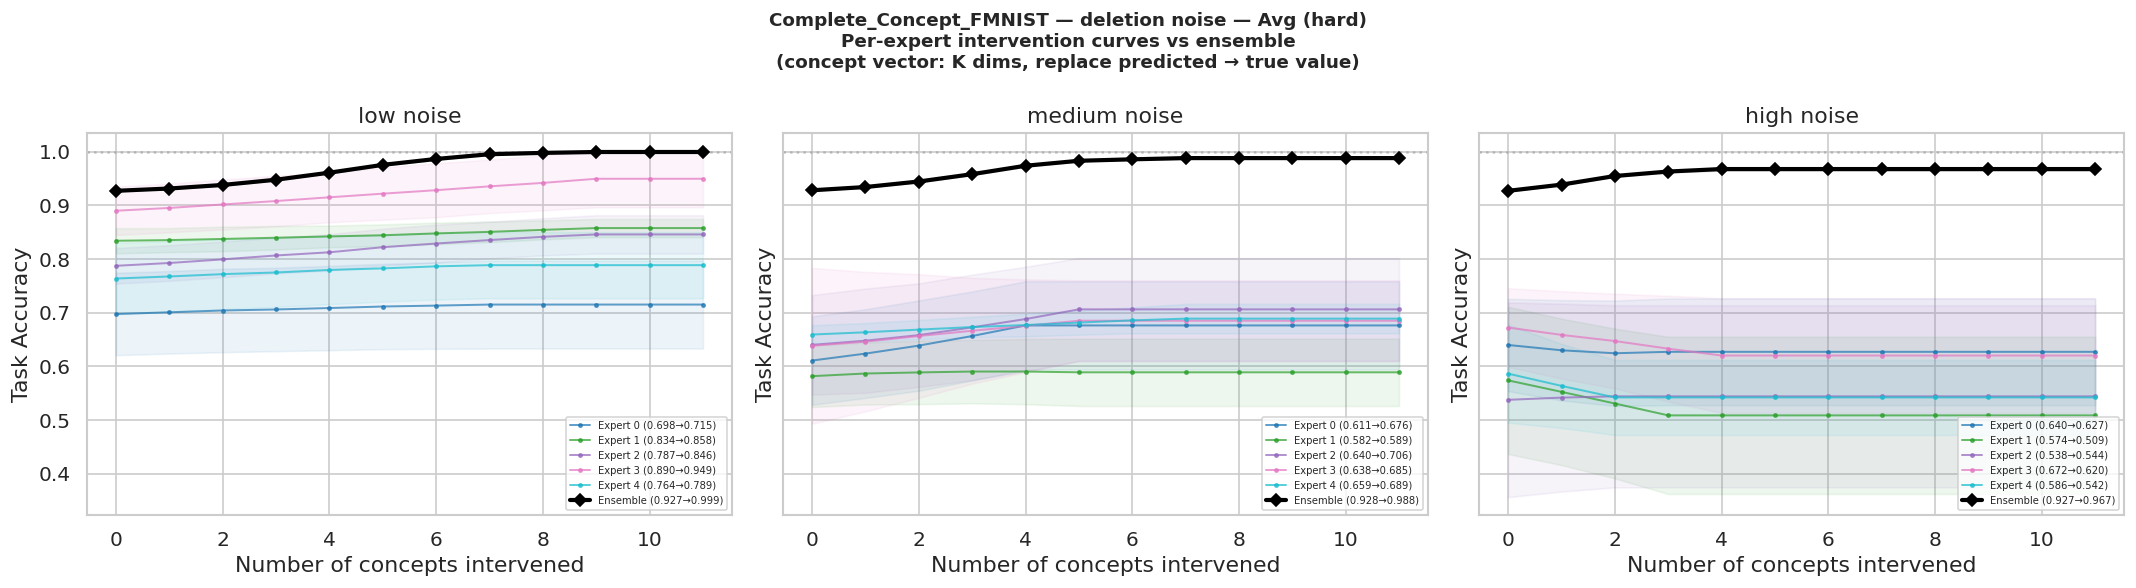

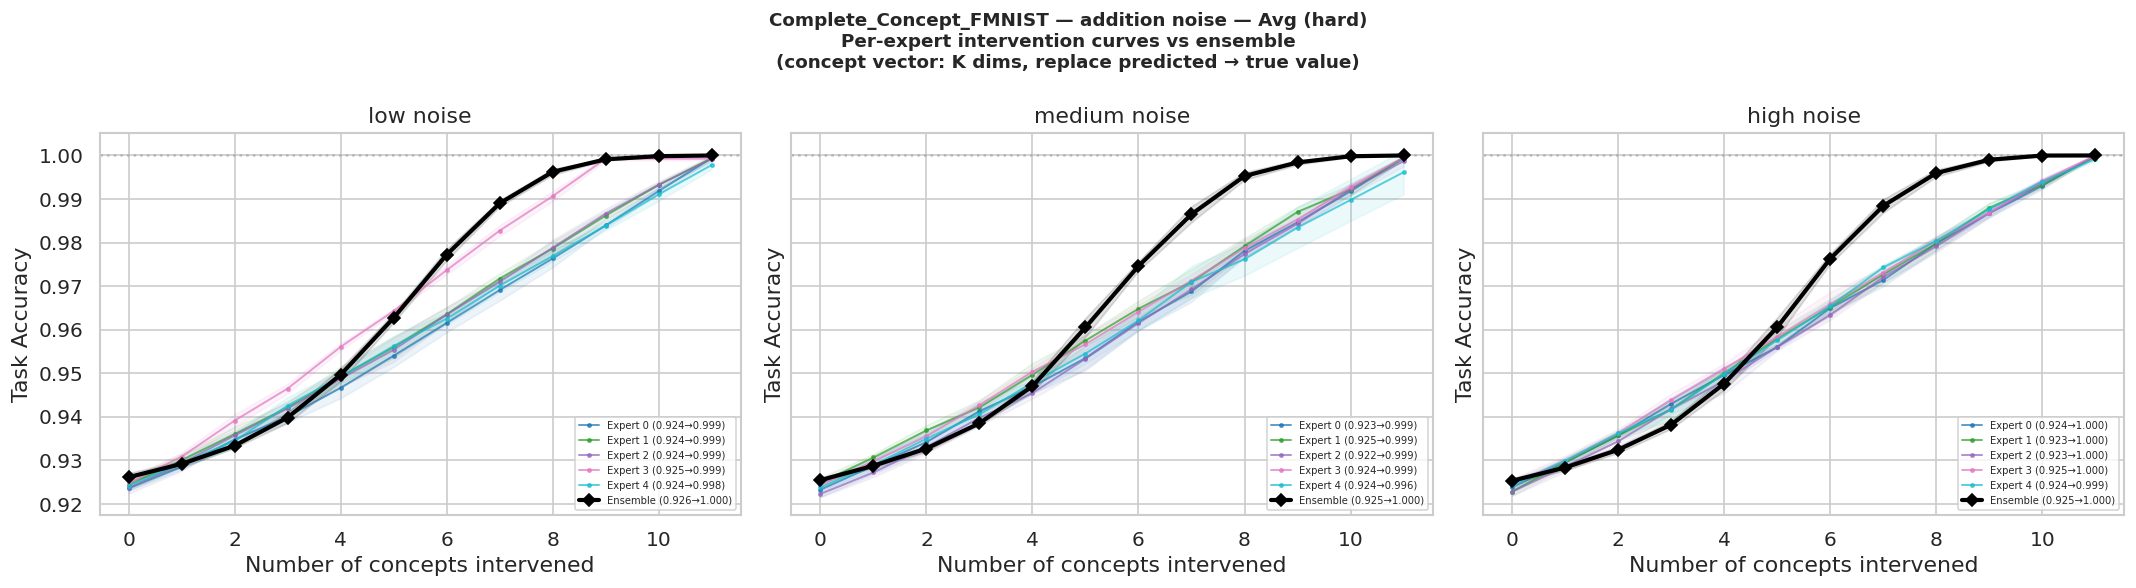

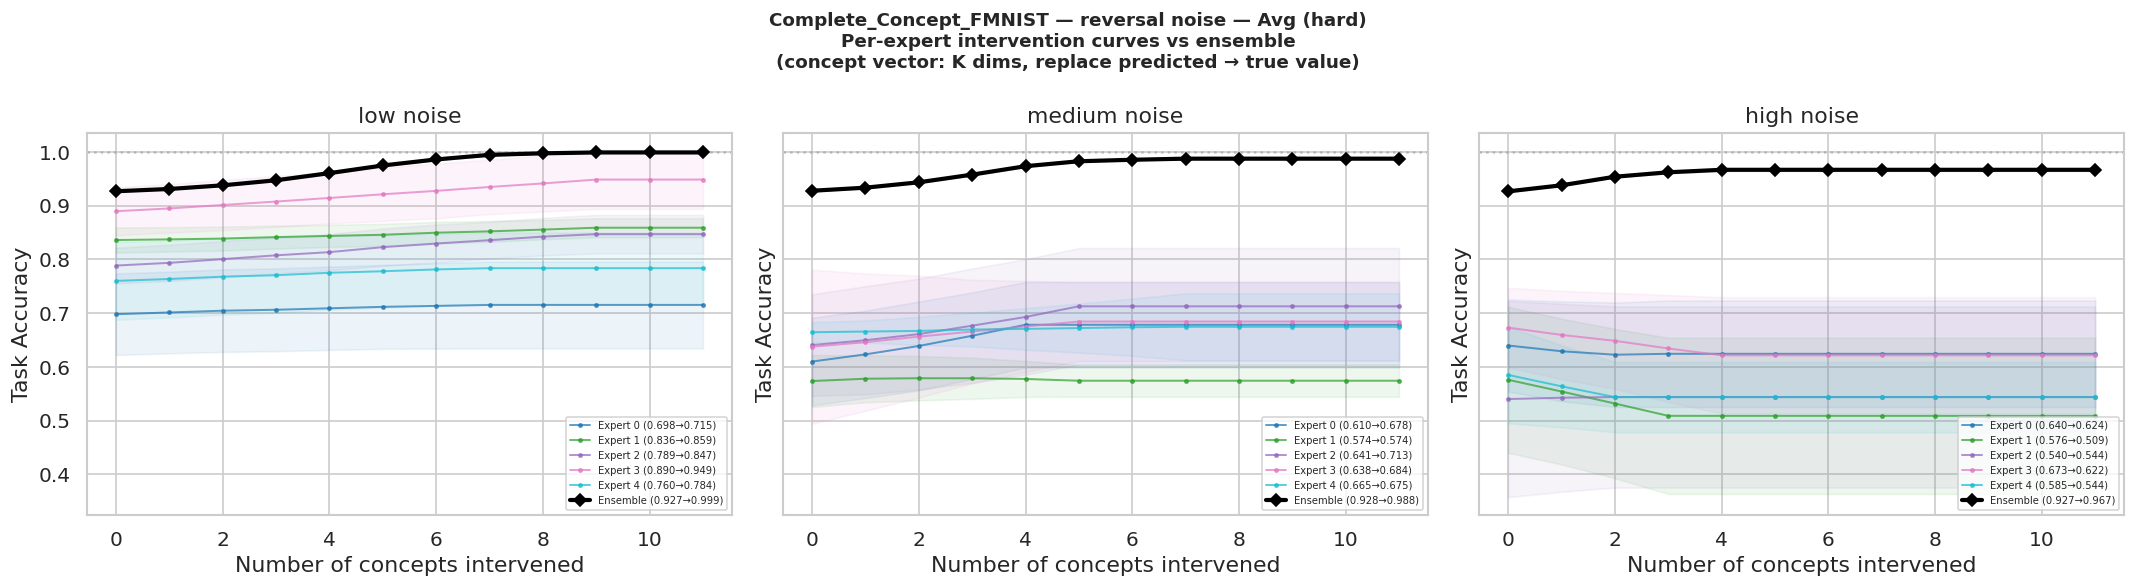

In [16]:
if len(per_expert_interv_df) == 0:
    print("No per-expert intervention data yet (jobs still running or old results).")
else:
    # One figure per dataset × action
    # Each subplot = one noise level
    # Lines = each expert (thin, colored) + ensemble (thick, black)
    # Also load ensemble intervention for comparison
    for dataset in DATASETS:
        for action in ACTIONS:
            sub_exp = per_expert_interv_df[
                (per_expert_interv_df["dataset"] == dataset) &
                (per_expert_interv_df["action"]  == action)
            ]
            sub_ens = interv_df[
                (interv_df["dataset"] == dataset) &
                (interv_df["action"]  == action)
            ] if len(interv_df) > 0 else pd.DataFrame()

            if sub_exp.empty: continue

            n_experts = sub_exp["expert"].nunique()
            etypes_present = sorted(sub_exp["etype"].unique())

            for etype in etypes_present:
                fig, axes = plt.subplots(1, len(LEVELS), figsize=(6*len(LEVELS), 5), sharey=True)
                fig.suptitle(
                    f"{dataset} — {action} noise — {ETYPE_LABEL.get(etype, etype)}\n"
                    f"Per-expert intervention curves vs ensemble\n"
                    f"(concept vector: K dims, replace predicted → true value)",
                    fontsize=11, fontweight="bold"
                )

                for ax, level in zip(axes, LEVELS):
                    lv_exp = sub_exp[
                        (sub_exp["noise_level"] == level) &
                        (sub_exp["etype"] == etype)
                    ]
                    if lv_exp.empty:
                        ax.set_title(f"{level} — no data"); continue

                    # Plot each expert as a thin colored line (mean across seeds)
                    expert_colors = plt.cm.tab10(np.linspace(0, 0.9, n_experts))
                    for m in range(n_experts):
                        exp_m = lv_exp[lv_exp["expert"] == m]
                        if exp_m.empty: continue
                        agg_m = (exp_m.groupby("num_interventions")["test_task_accuracy"]
                                      .agg(["mean", "std"]).reset_index())
                        ax.plot(agg_m["num_interventions"], agg_m["mean"],
                                color=expert_colors[m], linewidth=1.2, alpha=0.7,
                                marker=".", markersize=4,
                                label=f"Expert {m} ({agg_m['mean'].iloc[0]:.3f}→{agg_m['mean'].iloc[-1]:.3f})")
                        ax.fill_between(agg_m["num_interventions"],
                                        agg_m["mean"] - agg_m["std"],
                                        agg_m["mean"] + agg_m["std"],
                                        alpha=0.08, color=expert_colors[m])

                    # Plot ensemble as thick black line
                    if not sub_ens.empty:
                        lv_ens = sub_ens[
                            (sub_ens["noise_level"] == level) &
                            (sub_ens["etype"] == etype)
                        ]
                        if not lv_ens.empty:
                            agg_ens = (lv_ens.groupby("num_interventions")["test_task_accuracy"]
                                             .agg(["mean", "std"]).reset_index())
                            ax.plot(agg_ens["num_interventions"], agg_ens["mean"],
                                    color="black", linewidth=2.5, marker="D",
                                    markersize=5, zorder=5,
                                    label=f"Ensemble ({agg_ens['mean'].iloc[0]:.3f}→{agg_ens['mean'].iloc[-1]:.3f})")
                            ax.fill_between(agg_ens["num_interventions"],
                                            agg_ens["mean"] - agg_ens["std"],
                                            agg_ens["mean"] + agg_ens["std"],
                                            alpha=0.12, color="black")

                    ax.axhline(1.0, color="gray", linestyle=":", alpha=0.4)
                    ax.set_title(f"{level} noise")
                    ax.set_xlabel("Number of concepts intervened")
                    ax.set_ylabel("Task Accuracy")
                    ax.legend(fontsize=6, loc="lower right")

                plt.tight_layout()
                plt.savefig(
                    f"per_expert_interventions_{dataset}_{action}_{etype}.png",
                    dpi=150, bbox_inches="tight"
                )
                plt.show()

## 6c. Intervention Curves Annotated with CCI (Paper Figure 8 style)

Reproduces Figure 8 (right) from the CREAM paper, but for each ensemble experiment.

**CCI (Concept Channel Importance)** = ϕ_c / (ϕ_c + ϕ_y)
- CCI = 1.0 → model relies entirely on concepts → steepest intervention curve
- CCI = 0.5 → concepts and side channel equally important (threshold)
- CCI ≈ 0.0 → model ignores concepts → flat intervention curve

Per-expert CCI is approximated here as "how much does this expert's prediction
change when concepts are intervened" — the AUC gain from 0 to K interventions.

In [ ]:
# =========================================================================
# Figure 8 style: Intervention curves labeled with per-expert CCI
# Academic-quality version:
#   - Distinct colors per expert (colorblind-safe palette, NOT a gradient)
#   - CCI value in legend only (no overlapping end-of-line annotations)
#   - Distinct markers per expert
#   - Thick black ensemble line
#   - CCI shown as legend entry: "Expert 0  (CCI=0.43)"
#   - Colorbar removed (was confusing with yellow/green shades)
# =========================================================================

if len(interv_df) == 0:
    print("No intervention data yet.")
else:
    # Colorblind-safe palette — 5 distinct colors, clearly different
    EXPERT_COLORS  = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
    EXPERT_MARKERS = ["o", "s", "^", "D", "v"]
    EXPERT_LS      = ["-", "--", "-.", ":", (0,(3,1,1,1))]

    for dataset in DATASETS:
        for action in ACTIONS:
            sub_ens = interv_df[
                (interv_df["dataset"] == dataset) &
                (interv_df["action"]  == action)
            ]
            if sub_ens.empty: continue

            etypes_present = sorted(sub_ens["etype"].unique())

            for etype in etypes_present:
                sub_et = sub_ens[sub_ens["etype"] == etype]

                fig, axes = plt.subplots(1, len(LEVELS),
                                         figsize=(5*len(LEVELS), 4.5),
                                         sharey=True)
                fig.suptitle(
                    f"{dataset} — {action} — {ETYPE_LABEL.get(etype, etype)}\n"
                    f"Per-expert intervention curves with CCI\n"
                    f"Thick black = ensemble,  colored = individual experts",
                    fontsize=10, fontweight="bold"
                )

                for ax, level in zip(axes, LEVELS):
                    lv_ens = sub_et[sub_et["noise_level"] == level]
                    if lv_ens.empty:
                        ax.set_title(f"{level}"); continue

                    # ── Ensemble (thick black) ────────────────────────────────
                    agg_ens = (lv_ens.groupby("num_interventions")["test_task_accuracy"]
                                     .agg(["mean", "std"]).reset_index())
                    ax.plot(agg_ens["num_interventions"], agg_ens["mean"],
                            color="black", linewidth=2.5, marker="D",
                            markersize=6, zorder=10,
                            label=f"Ensemble ({agg_ens['mean'].iloc[0]:.3f}→{agg_ens['mean'].max():.3f})")
                    ax.fill_between(agg_ens["num_interventions"],
                                   agg_ens["mean"] - agg_ens["std"],
                                   agg_ens["mean"] + agg_ens["std"],
                                   alpha=0.10, color="black")

                    # ── Per-expert lines ──────────────────────────────────────
                    if len(per_expert_interv_df) > 0:
                        pe = per_expert_interv_df[
                            (per_expert_interv_df["dataset"] == dataset) &
                            (per_expert_interv_df["action"]  == action) &
                            (per_expert_interv_df["noise_level"] == level) &
                            (per_expert_interv_df["etype"] == etype)
                        ]
                        n_exp = pe["expert"].nunique() if not pe.empty else 0

                        for m in range(n_exp):
                            exp_m = pe[pe["expert"] == m]
                            if exp_m.empty: continue

                            # Fetch per-expert CCI for legend label
                            cci_m = None
                            if len(per_expert_cci_df) > 0:
                                cci_row = per_expert_cci_df[
                                    (per_expert_cci_df["dataset"] == dataset) &
                                    (per_expert_cci_df["action"]  == action) &
                                    (per_expert_cci_df["noise_level"] == level) &
                                    (per_expert_cci_df["etype"] == etype) &
                                    (per_expert_cci_df["expert"] == m)
                                ]
                                if not cci_row.empty and "CCI" in cci_row.columns:
                                    cci_m = max(0.0, float(cci_row["CCI"].mean()))

                            # CCI in legend label — no annotation on the line
                            if cci_m is not None:
                                label = f"Expert {m}  (CCI={cci_m:.2f})"
                            else:
                                label = f"Expert {m}"

                            color  = EXPERT_COLORS[m % len(EXPERT_COLORS)]
                            marker = EXPERT_MARKERS[m % len(EXPERT_MARKERS)]
                            ls     = EXPERT_LS[m % len(EXPERT_LS)]

                            agg_m = (exp_m.groupby("num_interventions")["test_task_accuracy"]
                                          .agg(["mean", "std"]).reset_index())
                            ax.plot(agg_m["num_interventions"], agg_m["mean"],
                                    color=color, linewidth=1.8, linestyle=ls,
                                    marker=marker, markersize=5, alpha=0.9,
                                    label=label)
                            ax.fill_between(agg_m["num_interventions"],
                                           agg_m["mean"] - agg_m["std"],
                                           agg_m["mean"] + agg_m["std"],
                                           alpha=0.08, color=color)

                    ax.axhline(1.0, color="gray", linestyle=":", alpha=0.3, linewidth=1)
                    ax.set_title(f"{level} noise", fontsize=10)
                    ax.set_xlabel("Number of interventions", fontsize=9)
                    if level == LEVELS[0]:
                        ax.set_ylabel("Task Accuracy", fontsize=9)
                    # Legend in lower-right, clean box
                    ax.legend(fontsize=7, loc="lower right",
                              framealpha=0.95, edgecolor="#cccccc",
                              handlelength=2.5)
                    ax.tick_params(labelsize=8)

                plt.tight_layout()
                plt.savefig(
                    f"cci_interv_per_expert_{dataset}_{action}_{etype}.png",
                    dpi=150, bbox_inches="tight"
                )
                plt.show()

In [ ]:
# =========================================================================
# Combined plot: Edge corruption numbers annotated on the intervention curve
# =========================================================================
# Each subplot shows ONE expert's intervention curve.
# Annotated with its own spurious/missing edge counts.
# The ensemble curve shown in all subplots for comparison.
# This directly shows the professor's observation:
#   - Experts with more MISSING edges → flatter curve (deletion effect)
#   - Experts with more SPURIOUS edges → steeper curve (addition effect)

if len(per_expert_interv_df) == 0:
    print("No per-expert intervention data yet.")
elif "total_spurious" not in per_expert_interv_df.columns:
    print("Edge info columns not present — re-run jobs with updated code.")
else:
    for dataset in DATASETS:
        for action in ACTIONS:
            sub_exp = per_expert_interv_df[
                (per_expert_interv_df["dataset"] == dataset) &
                (per_expert_interv_df["action"]  == action)
            ]
            sub_ens = interv_df[
                (interv_df["dataset"] == dataset) &
                (interv_df["action"]  == action)
            ] if len(interv_df) > 0 else pd.DataFrame()

            if sub_exp.empty: continue

            n_experts = sub_exp["expert"].nunique()
            etypes_present = sorted(sub_exp["etype"].unique())

            for etype in etypes_present:
                for level in LEVELS:
                    lv_exp = sub_exp[
                        (sub_exp["noise_level"] == level) &
                        (sub_exp["etype"] == etype)
                    ]
                    if lv_exp.empty: continue

                    # One subplot per expert + one for ensemble = n_experts+1 panels
                    n_cols = n_experts + 1
                    fig, axes = plt.subplots(1, n_cols,
                                             figsize=(4*n_cols, 5),
                                             sharey=True)
                    fig.suptitle(
                        f"{dataset} — {action}/{level} — {ETYPE_LABEL.get(etype, etype)}\n"
                        f"Per-expert intervention curve annotated with edge corruption\n"
                        f"(Gain = accuracy improvement from 0 to all interventions)",
                        fontsize=10, fontweight="bold"
                    )

                    # Get ensemble curve for comparison
                    ens_agg = None
                    if not sub_ens.empty:
                        lv_ens = sub_ens[
                            (sub_ens["noise_level"] == level) &
                            (sub_ens["etype"] == etype)
                        ]
                        if not lv_ens.empty:
                            ens_agg = (lv_ens.groupby("num_interventions")["test_task_accuracy"]
                                             .agg(["mean", "std"]).reset_index())

                    for m in range(n_experts):
                        ax = axes[m]
                        exp_m = lv_exp[lv_exp["expert"] == m]
                        if exp_m.empty: continue

                        # Intervention curve for this expert
                        agg_m = (exp_m.groupby("num_interventions")["test_task_accuracy"]
                                       .agg(["mean", "std"]).reset_index())

                        # Edge stats (same for all seeds/interventions)
                        spurious = exp_m["total_spurious"].mean()
                        missing  = exp_m["total_missing"].mean()
                        sp_c2y   = exp_m["c2y_spurious"].mean()
                        ms_c2y   = exp_m["c2y_missing"].mean()
                        gt_edges = exp_m["c2y_gt_edges"].mean()

                        # Color the line by dominant noise type
                        if spurious > missing:
                            line_color = "#e74c3c"   # red = addition dominated
                        elif missing > spurious:
                            line_color = "#3498db"   # blue = deletion dominated
                        else:
                            line_color = "#27ae60"

                        ax.plot(agg_m["num_interventions"], agg_m["mean"],
                                color=line_color, linewidth=2, marker="o", markersize=4,
                                label=f"Expert {m}")
                        ax.fill_between(agg_m["num_interventions"],
                                        agg_m["mean"] - agg_m["std"],
                                        agg_m["mean"] + agg_m["std"],
                                        alpha=0.15, color=line_color)

                        # Ensemble in gray for reference
                        if ens_agg is not None:
                            ax.plot(ens_agg["num_interventions"], ens_agg["mean"],
                                    color="black", linewidth=1.5, linestyle="--",
                                    alpha=0.5, label="Ensemble")

                        ax.axhline(1.0, color="gray", linestyle=":", alpha=0.3)

                        # Annotate with edge stats — the key info
                        stats_text = (
                            f"c2y edges:\n"
                            f"  GT:       {int(gt_edges)}\n"
                            f"  Spurious: {int(sp_c2y)}  (+)\n"
                            f"  Missing:  {int(ms_c2y)}  (-)\n"
                            f"Gain: +{(agg_m['mean'].max() - agg_m['mean'].iloc[0]):.3f}"
                        )
                        ax.text(0.04, 0.05, stats_text,
                                transform=ax.transAxes, fontsize=7,
                                verticalalignment="bottom",
                                bbox=dict(boxstyle="round,pad=0.3",
                                          facecolor="lightyellow", alpha=0.8))

                        ax.set_title(f"Expert {m}", fontsize=9)
                        ax.set_xlabel("# interventions")
                        ax.set_ylabel("Task Accuracy" if m == 0 else "")
                        if m == 0:
                            ax.legend(fontsize=6)

                    # Last panel: ensemble alone (larger view)
                    ax_ens = axes[n_experts]
                    if ens_agg is not None:
                        ax_ens.plot(ens_agg["num_interventions"], ens_agg["mean"],
                                    color="black", linewidth=2.5, marker="D",
                                    markersize=5, label="Ensemble")
                        ax_ens.fill_between(ens_agg["num_interventions"],
                                            ens_agg["mean"] - ens_agg["std"],
                                            ens_agg["mean"] + ens_agg["std"],
                                            alpha=0.15, color="black")
                        # Overlay all expert curves lightly for context
                        for m in range(n_experts):
                            exp_m = lv_exp[lv_exp["expert"] == m]
                            agg_m = (exp_m.groupby("num_interventions")["test_task_accuracy"]
                                           .mean().reset_index())
                            ax_ens.plot(agg_m["num_interventions"],
                                        agg_m["test_task_accuracy"],
                                        color=plt.cm.tab10(m), linewidth=0.8,
                                        alpha=0.4, linestyle="-")

                    # Total spurious/missing across all experts
                    total_sp = lv_exp.drop_duplicates(["expert","seed"])["total_spurious"].mean()
                    total_ms = lv_exp.drop_duplicates(["expert","seed"])["total_missing"].mean()
                    ax_ens.text(0.04, 0.05,
                                f"Avg across experts:\nSpurious: {total_sp:.1f}\nMissing:  {total_ms:.1f}",
                                transform=ax_ens.transAxes, fontsize=7,
                                verticalalignment="bottom",
                                bbox=dict(boxstyle="round,pad=0.3",
                                          facecolor="lightyellow", alpha=0.8))
                    ax_ens.axhline(1.0, color="gray", linestyle=":", alpha=0.3)
                    ax_ens.set_title("Ensemble", fontsize=9, fontweight="bold")
                    ax_ens.set_xlabel("# interventions")
                    ax_ens.legend(fontsize=6)

                    plt.tight_layout()
                    plt.savefig(
                        f"combined_interv_edges_{dataset}_{action}_{level}_{etype}.png",
                        dpi=150, bbox_inches="tight"
                    )
                    plt.show()

## 7. Task Accuracy: etype × noise level × action

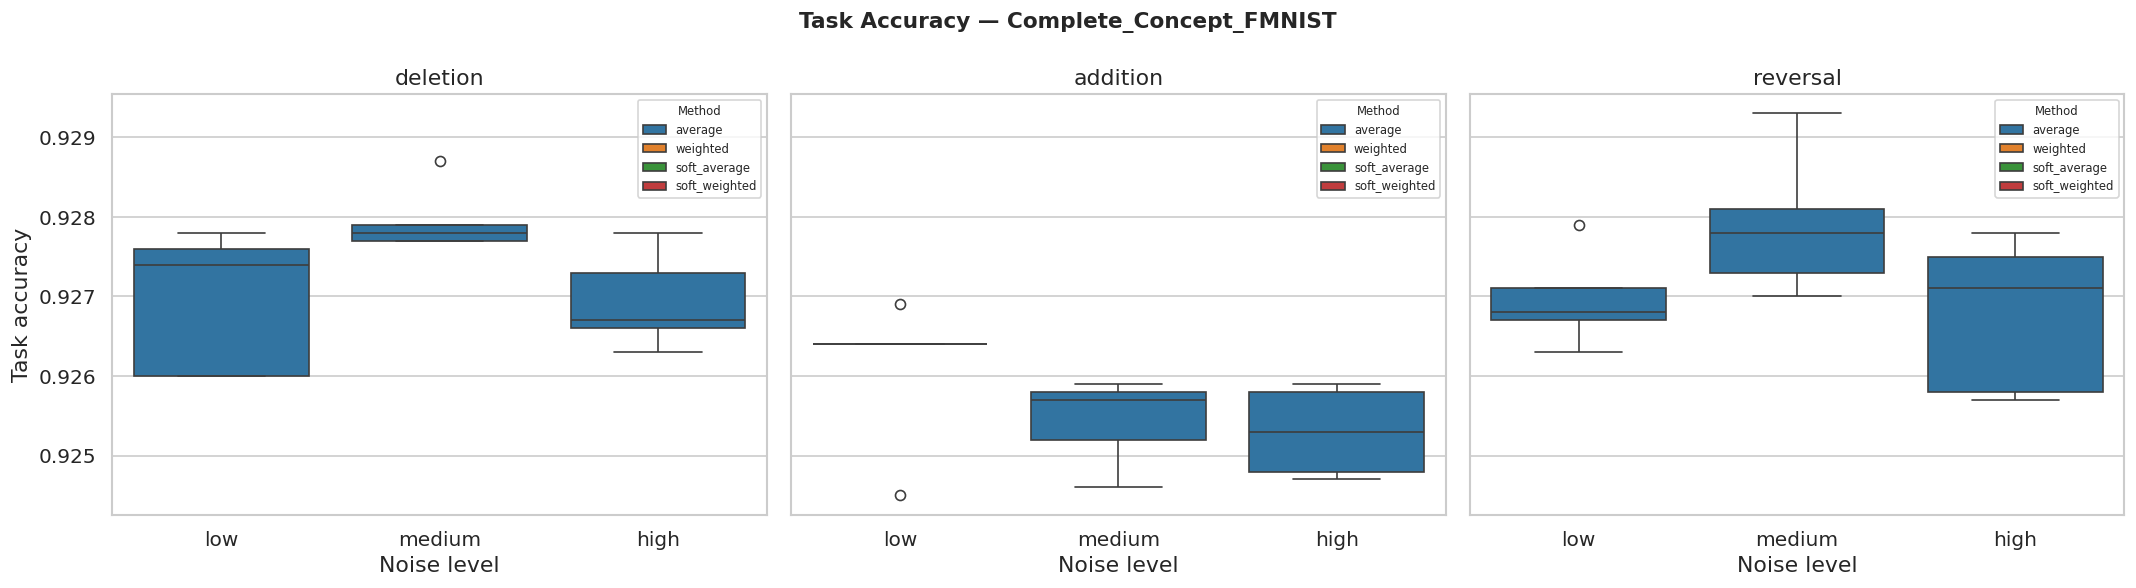

In [19]:
if len(ens_df) == 0:
    print("No data yet.")
else:
    for dataset in DATASETS:
        ds = ens_df[ens_df["dataset"] == dataset]
        if ds.empty: continue

        fig, axes = plt.subplots(1, len(ACTIONS), figsize=(6*len(ACTIONS), 5), sharey=True)
        fig.suptitle(f"Task Accuracy — {dataset}", fontsize=13, fontweight="bold")

        level_order = ["low", "medium", "high"]
        palette = {et: plt.cm.tab10(i) for i, et in enumerate(ETYPES)}

        for ax, action in zip(axes, ACTIONS):
            act = ds[ds["action"] == action]
            if act.empty: ax.set_title(f"{action} — no data"); continue

            sns.boxplot(
                data=act, x="noise_level", y="test_task_accuracy",
                hue="etype", order=level_order,
                hue_order=ETYPES, palette=palette, ax=ax
            )
            ax.set_title(f"{action}")
            ax.set_xlabel("Noise level")
            ax.set_ylabel("Task accuracy")
            ax.legend(title="Method", fontsize=7, title_fontsize=7)

        plt.tight_layout()
        plt.savefig(f"ensemble_task_acc_{dataset}.png", dpi=150, bbox_inches="tight")
        plt.show()

## 8. Learned Expert Weights π (weighted & soft_weighted only)

In [11]:
if len(ens_df) == 0:
    print("No data yet.")
elif "expert_weights" not in ens_df.columns:
    print("expert_weights column not found.")
else:
    import ast
    w_df = ens_df[ens_df["etype"].isin(["weighted", "soft_weighted"])].copy()
    w_df = w_df.dropna(subset=["expert_weights"])

    if w_df.empty:
        print("No expert weight data yet.")
    else:
        # Parse string list → actual list
        def parse_weights(x):
            try: return ast.literal_eval(x) if isinstance(x, str) else x
            except: return None
        w_df["weights"] = w_df["expert_weights"].apply(parse_weights)
        w_df = w_df.dropna(subset=["weights"])

        rows_w = []
        for _, row in w_df.iterrows():
            for m_idx, w in enumerate(row["weights"]):
                rows_w.append({"dataset": row["dataset"], "etype": row["etype"],
                                "action": row["action"], "noise_level": row["noise_level"],
                                "seed": row["seed"], "expert": m_idx, "weight": w})
        weights_long = pd.DataFrame(rows_w)

        for dataset in DATASETS:
            ds = weights_long[weights_long["dataset"] == dataset]
            if ds.empty: continue

            fig, axes = plt.subplots(2, len(ACTIONS),
                                     figsize=(5*len(ACTIONS), 8))
            fig.suptitle(f"Learned Expert Weights π — {dataset}",
                         fontsize=12, fontweight="bold")

            for col, action in enumerate(ACTIONS):
                for row_i, etype in enumerate(["weighted", "soft_weighted"]):
                    ax = axes[row_i, col]
                    sub = ds[(ds["action"] == action) & (ds["etype"] == etype)]
                    if sub.empty:
                        ax.set_title(f"{etype}/{action} — no data"); continue

                    agg = sub.groupby(["noise_level", "expert"])["weight"].mean().reset_index()
                    pivot = agg.pivot(index="expert", columns="noise_level", values="weight")
                    pivot = pivot.reindex(columns=LEVELS)
                    pivot.plot(kind="bar", ax=ax, colormap="viridis", legend=(col==0))
                    ax.set_title(f"{ETYPE_LABEL.get(etype, etype)}\n{action}")
                    ax.set_xlabel("Expert")
                    ax.set_ylabel("Mean π weight")
                    ax.axhline(1/len(pivot), color="red", linestyle="--",
                               alpha=0.5, label="uniform")

            plt.tight_layout()
            plt.show()

No expert weight data yet.


## 9. CCI & PFI Summary

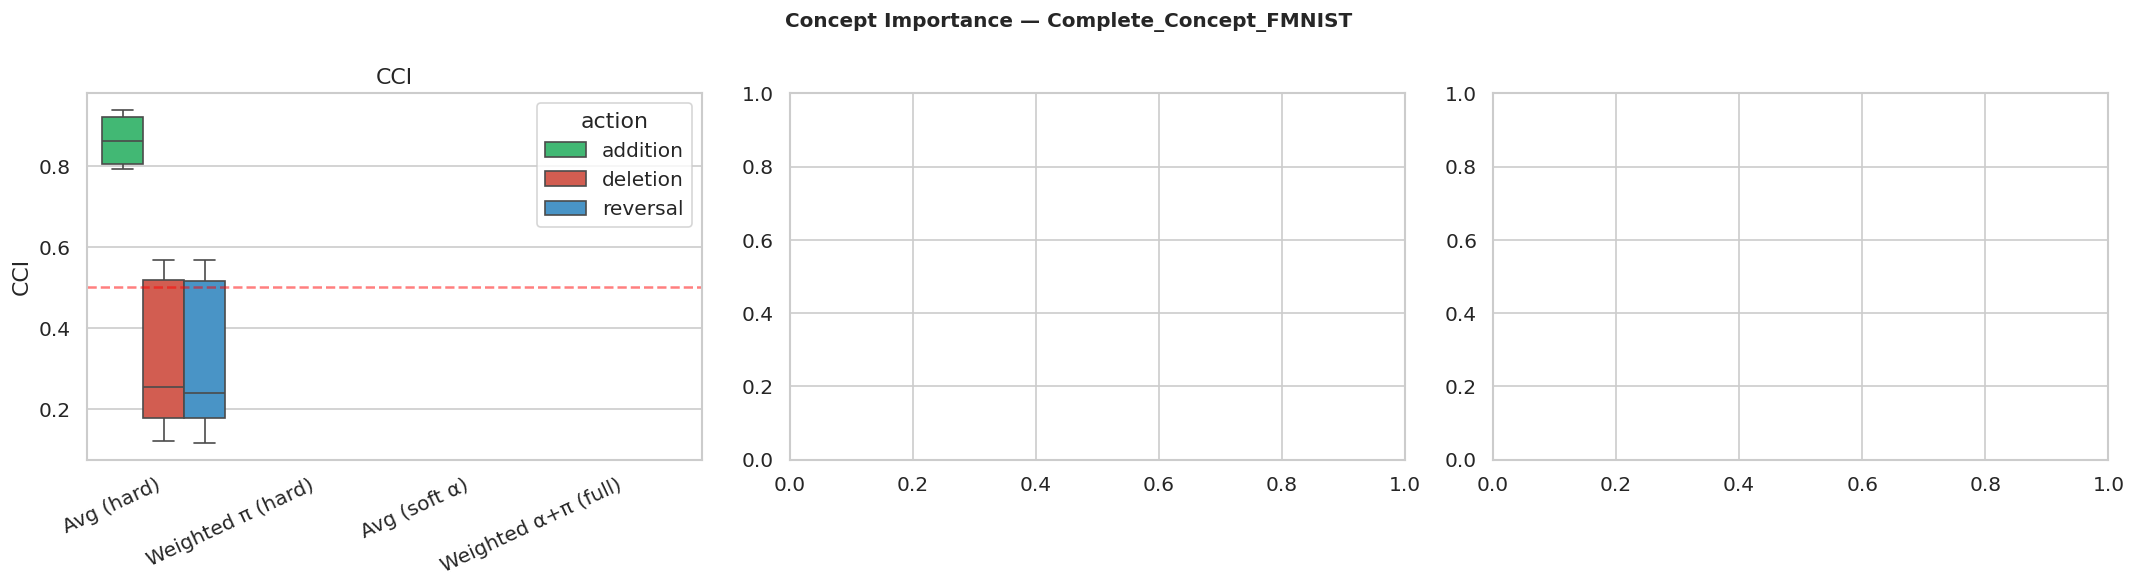

In [20]:
if len(ens_df) == 0:
    print("No data yet.")
else:
    cci_cols = [c for c in ["CCI", "PFI_concept_importance", "PFI_side_importance"]
                if c in ens_df.columns]
    if not cci_cols:
        print("CCI/PFI columns not found yet.")
    else:
        for dataset in DATASETS:
            ds = ens_df[ens_df["dataset"] == dataset].dropna(subset=cci_cols[:1])
            if ds.empty: continue

            fig, axes = plt.subplots(1, len(cci_cols), figsize=(6*len(cci_cols), 5))
            if len(cci_cols) == 1: axes = [axes]
            fig.suptitle(f"Concept Importance — {dataset}", fontsize=12, fontweight="bold")

            for ax, metric in zip(axes, cci_cols):
                sub = ds.dropna(subset=[metric])
                if sub.empty: continue
                sns.boxplot(data=sub, x="etype", y=metric,
                            hue="action", order=ETYPES, ax=ax,
                            palette=ACTION_COLOR)
                ax.set_title(metric)
                ax.set_xticklabels([ETYPE_LABEL.get(e, e) for e in ETYPES],
                                   rotation=25, ha="right")
                ax.set_xlabel("")
                if metric == "CCI":
                    ax.axhline(0.5, color="red", linestyle="--", alpha=0.5,
                               label="0.5 threshold")

            plt.tight_layout()
            plt.show()

## 10. Robustness Plot: Accuracy vs Noise Level (H1)

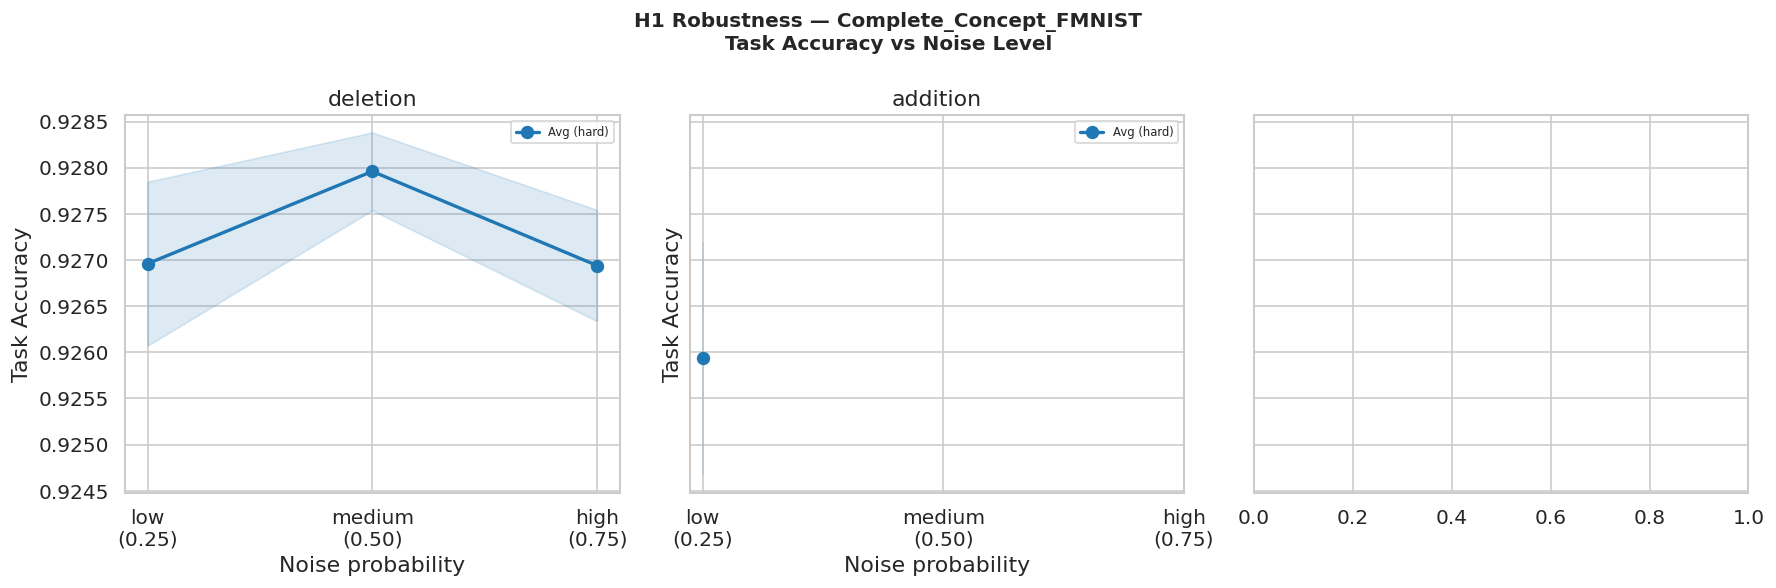

In [13]:
if len(ens_df) == 0:
    print("No data yet.")
else:
    # Key plot for H1: as noise increases, which method degrades least?
    level_num = {"low": 0.25, "medium": 0.50, "high": 0.75}

    for dataset in DATASETS:
        ds = ens_df[ens_df["dataset"] == dataset].copy()
        if ds.empty: continue
        ds["noise_prob"] = ds["noise_level"].map(level_num)
        ds = ds.dropna(subset=["noise_prob", "test_task_accuracy"])

        fig, axes = plt.subplots(1, len(ACTIONS), figsize=(5*len(ACTIONS), 5), sharey=True)
        fig.suptitle(f"H1 Robustness — {dataset}\nTask Accuracy vs Noise Level",
                     fontsize=12, fontweight="bold")

        for ax, action in zip(axes, ACTIONS):
            act = ds[ds["action"] == action]
            if act.empty: continue

            agg = act.groupby(["etype", "noise_prob"])["test_task_accuracy"].agg(
                ["mean", "std"]).reset_index()

            for i_et, etype in enumerate(ETYPES):
                sub = agg[agg["etype"] == etype]
                if sub.empty: continue
                color  = plt.cm.tab10(i_et)
                marker = ETYPE_MARKER.get(etype, "o")
                ax.plot(sub["noise_prob"], sub["mean"],
                        label=ETYPE_LABEL.get(etype, etype),
                        color=color, marker=marker, markersize=7, linewidth=2)
                ax.fill_between(sub["noise_prob"],
                                sub["mean"] - sub["std"],
                                sub["mean"] + sub["std"],
                                alpha=0.15, color=color)

            ax.set_title(f"{action}")
            ax.set_xlabel("Noise probability")
            ax.set_ylabel("Task Accuracy")
            ax.set_xticks([0.25, 0.50, 0.75])
            ax.set_xticklabels(["low\n(0.25)", "medium\n(0.50)", "high\n(0.75)"])
            ax.legend(fontsize=7)

        plt.tight_layout()
        plt.savefig(f"ensemble_robustness_{dataset}.png", dpi=150, bbox_inches="tight")
        plt.show()

## 11. Export LaTeX-ready Summary Table

In [ ]:
if len(ens_df) > 0:
    key = ["test_task_accuracy", "test_concept_accuracy", "CCI",
           "PFI_concept_importance", "intervention_acc_max"]
    available = [c for c in key if c in ens_df.columns]

    agg = (ens_df.groupby(["dataset", "action", "noise_level", "etype"])[available]
                 .agg(["mean", "std"])
                 .round(4))
    agg.to_csv("mcream_ensemble_summary.csv")
    print("Saved: mcream_ensemble_summary.csv")
    display(agg)